In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import datetime
import seaborn as sns
import missingno as msno
import firebase_admin
from firebase_admin import credentials, db
from datetime import datetime  # Untuk konversi timestamp ke human-readable
sns.set_theme(style="whitegrid")
%matplotlib inline 

In [2]:
# Konfigurasi database sumber
source_cred = credentials.Certificate("D:/staklimjerukagung-firebase-adminsdk-kcfma-e091165a9b.json")
firebase_admin.initialize_app(source_cred, {
    'databaseURL': 'https://staklimjerukagung-default-rtdb.asia-southeast1.firebasedatabase.app/'
})

In [40]:
# Input readable date
start_readable_date = "01-01-2025 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
end_readable_date = "31-12-2025 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS

# Convert readable date to Unix timestamp
start_timestamp = int(datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(start_timestamp) # Convert to string and print
end_timestamp = int(datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(end_timestamp) # Convert to string and print


1735664400
1767200399


In [41]:
def fetch_weather_data(station_id, start_ts, end_ts):
    """
    Mengambil data cuaca dari Firebase Realtime Database untuk stasiun dan rentang waktu tertentu.

    Args:
        station_id (str): ID stasiun cuaca (contoh: 'id-03', 'id-04').
        start_ts (int): Timestamp awal (epoch time).
        end_ts (int): Timestamp akhir (epoch time).

    Returns:
        dict: Hasil data dari Firebase, atau None jika tidak ada data.
    """
    try:
        # Membuat path referensi secara dinamis berdasarkan station_id
        ref_path = f'/auto_weather_stat/{station_id}/data'
        ref_data = db.reference(ref_path)

        # Membuat query dengan rentang waktu
        query_data = ref_data.order_by_key().start_at(str(start_ts)).end_at(str(end_ts))

        # Mengambil dan mengembalikan hasil
        results = query_data.get()
        print(f"Data untuk stasiun {station_id} berhasil diambil.")
        return results
    except Exception as e:
        print(f"Terjadi error saat mengambil data untuk {station_id}: {e}")
        return None

# 2. Siapkan daftar ID stasiun yang ingin diambil datanya
station_ids = ['id-03','id-05'] # Mudah untuk menambah stasiun baru

# 3. Gunakan loop untuk mengambil data semua stasiun dan simpan hasilnya
all_weather_data = {}
for station in station_ids:
    # Panggil fungsi untuk setiap stasiun
    data = fetch_weather_data(station, start_timestamp, end_timestamp)
    if data:
        all_weather_data[station] = data

Data untuk stasiun id-03 berhasil diambil.
Data untuk stasiun id-05 berhasil diambil.


In [42]:
def create_weather_dataframe(data_dict, source_name):
    """
    Mengubah dictionary data cuaca menjadi DataFrame Pandas.

    Args:
        data_dict (dict): Dictionary berisi data cuaca yang diambil dari Firebase.
        source_name (str): Nama atau ID sumber data untuk keperluan logging/print.

    Returns:
        pandas.DataFrame: DataFrame yang sudah diformat, atau None jika input kosong.
    """
    # Periksa apakah ada data untuk diproses
    if not data_dict:
        print(f"Tidak ada data dari sumber '{source_name}' untuk diproses.")
        return None

    try:
        # Mengubah data dari dictionary menjadi DataFrame
        # 'orient="index"' menjadikan key dari dictionary sebagai baris awal
        df = pd.DataFrame.from_dict(data_dict, orient='index')

        # Memastikan kolom 'timestamp' ada.
        # Jika 'timestamp' bukan salah satu kolom, berarti ia adalah indeks.
        if 'timestamp' not in df.columns:
            df.index.name = 'timestamp'  # Beri nama pada indeks
            df.reset_index(inplace=True) # Pindahkan indeks menjadi kolom biasa

        print(f"DataFrame untuk sumber '{source_name}' berhasil dibuat.")
        return df
        
    except Exception as e:
        print(f"Gagal membuat DataFrame untuk '{source_name}': {e}")
        return None


# 2. Siapkan dictionary kosong untuk menampung DataFrame yang akan kita buat
weather_dataframes = {}

# 3. Loop melalui setiap item di all_weather_data
#    Gunakan .items() untuk mendapatkan key (nama stasiun) dan value (datanya)
for station_id, raw_data in all_weather_data.items():
    
    # Panggil fungsi baru kita untuk mengubah data mentah menjadi DataFrame
    df = create_weather_dataframe(raw_data, station_id)
    
    # Jika DataFrame berhasil dibuat, simpan ke dalam dictionary kita
    if df is not None:
        weather_dataframes[station_id] = df

# 4. Sekarang semua DataFrame Anda tersimpan rapi di satu tempat
print("\n--- Verifikasi Hasil ---")

DataFrame untuk sumber 'id-03' berhasil dibuat.
DataFrame untuk sumber 'id-05' berhasil dibuat.

--- Verifikasi Hasil ---


In [43]:
def save_weather_data_to_csv(data_dict, output_folder='weather_data_csv'):
    """
    Menyimpan setiap DataFrame dalam dictionary ke file CSV terpisah.

    Args:
        data_dict (dict): Dictionary berisi {station_id: DataFrame}.
        output_folder (str): Nama folder untuk menyimpan file CSV.
    """
    # Pastikan modul os terimport (biasanya sudah di cell paling atas, tapi untuk keamanan)
    import os

    # Buat folder jika belum ada
    if not os.path.exists(output_folder):
        try:
            os.makedirs(output_folder)
            print(f"Folder '{output_folder}' berhasil dibuat.")
        except OSError as e:
            print(f"Gagal membuat folder '{output_folder}': {e}")
            return

    print(f"\n--- Menyimpan Data ke Folder '{output_folder}' ---")

    for station_id, df in data_dict.items():
        try:
            # Buat nama file yang aman
            filename = f"weather_data_{station_id}.csv"
            file_path = os.path.join(output_folder, filename)

            # Simpan ke CSV
            # index=False karena timestamp biasanya sudah di-reset menjadi kolom di langkah sebelumnya
            df.to_csv(file_path, index=False)
            print(f"Berhasil menyimpan: {filename}")
        except Exception as e:
            print(f"Gagal menyimpan data untuk {station_id}: {e}")

# Panggil fungsi untuk menyimpan data
save_weather_data_to_csv(weather_dataframes)


--- Menyimpan Data ke Folder 'weather_data_csv' ---
Berhasil menyimpan: weather_data_id-03.csv
Berhasil menyimpan: weather_data_id-05.csv


In [44]:
def load_weather_data_from_csv(input_folder='weather_data_csv'):
    """
    Membaca kembali file CSV dari folder ke dalam dictionary DataFrame.

    Args:
        input_folder (str): Nama folder tempat file CSV disimpan.

    Returns:
        dict: Dictionary berisi {station_id: DataFrame}.
    """
    import os
    import pandas as pd

    loaded_data = {}

    # Cek apakah folder ada
    if not os.path.exists(input_folder):
        print(f"Folder '{input_folder}' tidak ditemukan.")
        return loaded_data

    print(f"\n--- Membaca Data dari Folder '{input_folder}' ---")

    try:
        # Loop semua file di folder
        for filename in os.listdir(input_folder):
            if filename.endswith(".csv") and filename.startswith("weather_data_"):
                # Ekstrak station_id dari nama file (weather_data_id-03.csv -> id-03)
                station_id = filename.replace("weather_data_", "").replace(".csv", "")
                
                file_path = os.path.join(input_folder, filename)
                
                # Baca CSV ke DataFrame
                df = pd.read_csv(file_path)
                
                # Simpan ke dictionary
                loaded_data[station_id] = df
                print(f"Berhasil memuat: {station_id} ({len(df)} baris)")
                
        return loaded_data

    except Exception as e:
        print(f"Terjadi kesalahan saat membaca data: {e}")
        return {}


# Uncomment baris di bawah ini jika ingin me-load data dari CSV menggantikan data dari API
weather_dataframes = load_weather_data_from_csv()


--- Membaca Data dari Folder 'weather_data_csv' ---
Berhasil memuat: id-03 (576077 baris)
Berhasil memuat: id-04 (169839 baris)
Berhasil memuat: id-05 (520249 baris)


In [45]:
if 'id-03' in weather_dataframes:
    print("\nMenampilkan 5 baris pertama dari DataFrame 'id-03':")
    print(weather_dataframes['id-03'].head())

if 'id-05' in weather_dataframes:
    print("\nMenampilkan 5 baris pertama dari DataFrame 'id-05':")
    print(weather_dataframes['id-05'].head())


Menampilkan 5 baris pertama dari DataFrame 'id-03':
     dew  humidity  pressure  temperature     timestamp  volt  rainfall  \
0  24.72     100.0   1010.84        24.72  1.735664e+09  4.07       NaN   
1  24.72     100.0   1010.84        24.72  1.735664e+09  4.07       NaN   
2  24.73     100.0   1010.79        24.73  1.735664e+09  4.07       NaN   
3  24.73     100.0   1010.79        24.73  1.735665e+09  4.07       NaN   
4  24.74     100.0   1010.90        24.74  1.735665e+09  4.07       NaN   

   rainrate  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  

Menampilkan 5 baris pertama dari DataFrame 'id-05':
        dew  humidity  pressure  rainfall  rainrate  temperature   timestamp  \
0  27.74858  97.23300  1011.023   11.7348       0.0     28.23109  1742366497   
1  27.58560  96.49294  1011.033   11.7348       0.0     28.19905  1742366512   
2  27.56910  96.34035  1011.045   11.7348       0.0     28.20973  1742366527   
3  27.68267  96.81529  1011.038   11.73

In [46]:
def convert_timestamp_to_int(df, column_name='timestamp'):
    """
    Mengubah tipe data kolom tertentu dalam DataFrame menjadi integer.

    Args:
        df (pd.DataFrame): DataFrame yang akan dimodifikasi.
        column_name (str): Nama kolom yang akan diubah tipenya. Defaultnya adalah 'timestamp'.

    Returns:
        pd.DataFrame: DataFrame yang telah dimodifikasi, atau DataFrame asli jika kolom tidak ditemukan.
    """
    # Periksa apakah input adalah DataFrame yang valid dan memiliki kolom yang dimaksud
    if isinstance(df, pd.DataFrame) and column_name in df.columns:
        try:
            df[column_name] = df[column_name].astype(int)
            print(f"Kolom '{column_name}' berhasil diubah menjadi tipe integer.")
        except Exception as e:
            print(f"Gagal mengubah tipe data kolom '{column_name}': {e}")
    else:
        # Memberi tahu pengguna jika kolom tidak ada di DataFrame
        print(f"Peringatan: Kolom '{column_name}' tidak ditemukan dalam DataFrame.")
        
    return df



In [47]:
# ==============================================================================
# PERBAIKAN: HANDLING MISSING VALUES PADA TIMESTAMP
# ==============================================================================

for station_id in weather_dataframes:
    print(f"🔄 Memproses DataFrame untuk stasiun: {station_id}")
    
    # Ambil dataframe sementara
    df_temp = weather_dataframes[station_id]
    
    # 1. CEK & HAPUS TIMESTAMP YANG KOSONG (NaN)
    # Hitung jumlah yang kosong
    missing_count = df_temp['timestamp'].isna().sum()
    
    if missing_count > 0:
        print(f"   ⚠️ PERINGATAN: Ditemukan {missing_count} baris dengan timestamp kosong (NaN).")
        print("   -> Menghapus baris tersebut agar konversi berhasil...")
        
        # Hapus baris yang timestamp-nya NaN
        df_temp = df_temp.dropna(subset=['timestamp'])
        
    # 2. KONVERSI KE INTEGER
    # Pastikan tipe data float dulu biar aman, baru ke int
    try:
        df_temp['timestamp'] = df_temp['timestamp'].astype(float).astype(int)
        print("Sukses: Timestamp diubah ke Integer.")
    except Exception as e:
        print(f"Gagal: {e}")

    # Simpan kembali ke dictionary
    weather_dataframes[station_id] = df_temp

print("\n--- Memeriksa tipe data SETELAH perbaikan ---")
# Cek sampel satu stasiun
if 'id-03' in weather_dataframes:
    print(f"Tipe data id-03: {weather_dataframes['id-03']['timestamp'].dtype}")

🔄 Memproses DataFrame untuk stasiun: id-03
   ⚠️ PERINGATAN: Ditemukan 2 baris dengan timestamp kosong (NaN).
   -> Menghapus baris tersebut agar konversi berhasil...
Sukses: Timestamp diubah ke Integer.
🔄 Memproses DataFrame untuk stasiun: id-04
Sukses: Timestamp diubah ke Integer.
🔄 Memproses DataFrame untuk stasiun: id-05
Sukses: Timestamp diubah ke Integer.

--- Memeriksa tipe data SETELAH perbaikan ---
Tipe data id-03: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_3736\2454276808.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['timestamp'] = df_temp['timestamp'].astype(float).astype(int)


In [48]:
def format_datetime_column(df, column_name='timestamp', target_tz='Asia/Jakarta'):
    """
    Mengonversi kolom timestamp (integer) ke datetime dengan zona waktu tertentu.

    Proses:
    1. Mengubah integer timestamp (detik) menjadi datetime dalam UTC.
    2. Mengonversi datetime dari UTC ke zona waktu target (default: 'Asia/Jakarta').

    Args:
        df (pd.DataFrame): DataFrame yang akan diproses.
        column_name (str): Nama kolom timestamp. Defaultnya 'timestamp'.
        target_tz (str): Zona waktu target. Defaultnya 'Asia/Jakarta'.

    Returns:
        pd.DataFrame: DataFrame yang telah dimodifikasi.
    """
    # Pastikan input adalah DataFrame dan kolomnya ada
    if not isinstance(df, pd.DataFrame) or column_name not in df.columns:
        print(f"Peringatan: Input bukan DataFrame atau kolom '{column_name}' tidak ditemukan.")
        return df

    try:
        # Langkah 1: Konversi dari integer (epoch seconds) ke datetime UTC
        df[column_name] = pd.to_datetime(df[column_name], unit='s', utc=True)
        
        # Langkah 2: Konversi zona waktu dari UTC ke target_tz (WIB)
        df[column_name] = df[column_name].dt.tz_convert(target_tz)
        
        print(f"Kolom '{column_name}' berhasil diformat ke zona waktu {target_tz}.")
    except Exception as e:
        print(f"Gagal memformat kolom '{column_name}': {e}")
        
    return df

In [49]:
for station_id in weather_dataframes:
    print(f"Memproses DataFrame untuk stasiun: {station_id}")
    weather_dataframes[station_id] = format_datetime_column(weather_dataframes[station_id])

print("\n" + "="*40 + "\n")

Memproses DataFrame untuk stasiun: id-03
Kolom 'timestamp' berhasil diformat ke zona waktu Asia/Jakarta.
Memproses DataFrame untuk stasiun: id-04
Kolom 'timestamp' berhasil diformat ke zona waktu Asia/Jakarta.
Memproses DataFrame untuk stasiun: id-05
Kolom 'timestamp' berhasil diformat ke zona waktu Asia/Jakarta.




In [50]:
def add_time_features(df, column_name='timestamp'):
    """
    Menambahkan kolom-kolom berbasis waktu (jam, hari, bulan, dll.) ke DataFrame.

    Proses:
    1. Memastikan kolom waktu berformat datetime.
    2. Mengurutkan DataFrame berdasarkan kolom waktu tersebut.
    3. Mengekstrak dan menambahkan kolom 'hour', 'minute', 'day', 'week', 'month', dan 'year'.

    Args:
        df (pd.DataFrame): DataFrame input.
        column_name (str): Nama kolom datetime yang akan diproses.

    Returns:
        pd.DataFrame: DataFrame baru dengan kolom-kolom waktu tambahan.
    """
    if not isinstance(df, pd.DataFrame) or column_name not in df.columns:
        print(f"Peringatan: Input bukan DataFrame atau kolom '{column_name}' tidak ditemukan.")
        return df

    try:
        # Langkah 1: Memastikan kolom 'timestamp' berformat datetime (sebagai pengaman)
        df[column_name] = pd.to_datetime(df[column_name])

        # Langkah 2: Mengurutkan data berdasarkan 'timestamp'
        df = df.sort_values(by=column_name)

        # Langkah 3: Menambahkan kolom-kolom waktu
        df['hour'] = df[column_name].dt.hour
        df['minute'] = df[column_name].dt.minute
        df['day'] = df[column_name].dt.day
        df['week'] = df[column_name].dt.isocalendar().week.astype(int) # .isocalendar() menghasilkan object kompleks
        df['month'] = df[column_name].dt.month
        df['year'] = df[column_name].dt.year
        
        print(f"Fitur waktu berhasil ditambahkan ke DataFrame.")
    except Exception as e:
        print(f"Gagal menambahkan fitur waktu: {e}")
        
    return df

In [51]:
for station_id in weather_dataframes:
    print(f"--- Memproses DataFrame untuk stasiun: {station_id} ---")
    weather_dataframes[station_id] = add_time_features(weather_dataframes[station_id])

print("\n" + "="*50 + "\n")

# Verifikasi hasil dari dictionary
print("Hasil akhir untuk 'id-03' dari dictionary:")
print(weather_dataframes['id-03'].head())

--- Memproses DataFrame untuk stasiun: id-03 ---
Fitur waktu berhasil ditambahkan ke DataFrame.
--- Memproses DataFrame untuk stasiun: id-04 ---
Fitur waktu berhasil ditambahkan ke DataFrame.
--- Memproses DataFrame untuk stasiun: id-05 ---
Fitur waktu berhasil ditambahkan ke DataFrame.


Hasil akhir untuk 'id-03' dari dictionary:
     dew  humidity  pressure  temperature                 timestamp  volt  \
0  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00  4.07   
1  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00  4.07   
2  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00  4.07   
3  24.73     100.0   1010.79        24.73 2025-01-01 00:01:41+07:00  4.07   
4  24.74     100.0   1010.90        24.74 2025-01-01 00:02:37+07:00  4.07   

   rainfall  rainrate  hour  minute  day  week  month  year  
0       NaN       NaN     0       0    1     1      1  2025  
1       NaN       NaN     0       0    1     1      1  2025  
2       NaN       

In [52]:
# Mengekstrak setiap DataFrame ke variabel terpisah
cuaca3 = weather_dataframes['id-03'] if 'id-03' in weather_dataframes else None
cuaca4 = weather_dataframes['id-04'] if 'id-04' in weather_dataframes else None
cuaca5 = weather_dataframes['id-05'] if 'id-05' in weather_dataframes else None

In [53]:
# 3) Cari pressure minimum
p_min = cuaca3['pressure'].min()

# 4) Ambil semua timestamp saat pressure minimum
rows_min = cuaca3[cuaca3['pressure'] == p_min].sort_values('timestamp')

# 5) Tampilkan hasil
print(f"Pressure minimum: {p_min}")
print(f"Tanggal pertama saat minimum: {rows_min['timestamp'].iloc[0]}")
print("\nSemua tanggal saat pressure minimum:")
print(rows_min[['timestamp', 'pressure']])

Pressure minimum: 1001.92
Tanggal pertama saat minimum: 2025-02-05 16:00:00+07:00

Semua tanggal saat pressure minimum:
                      timestamp  pressure
86627 2025-02-05 16:00:00+07:00   1001.92
86628 2025-02-05 16:00:01+07:00   1001.92


=== Informasi Missing Values dalam cuaca3 ===

dew                 0
humidity            0
pressure            0
temperature         0
timestamp           0
volt                0
rainfall       573683
rainrate       573683
hour                0
minute              0
day                 0
week                0
month               0
year                0
dtype: int64


=== Persentase Missing Values ===

dew             0.000000
humidity        0.000000
pressure        0.000000
temperature     0.000000
timestamp       0.000000
volt            0.000000
rainfall       99.584776
rainrate       99.584776
hour            0.000000
minute          0.000000
day             0.000000
week            0.000000
month           0.000000
year            0.000000
dtype: float64


=== Visualisasi Missing Values ===


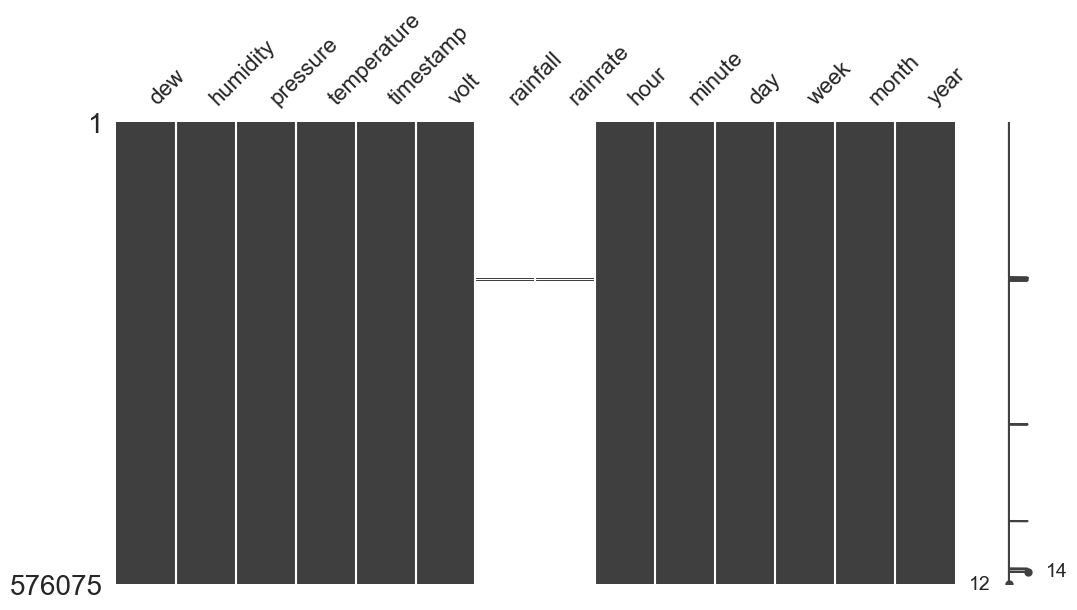


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 573683

Contoh baris dengan null:
     dew  humidity  pressure  temperature                 timestamp  volt  \
0  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00  4.07   
1  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00  4.07   
2  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00  4.07   
3  24.73     100.0   1010.79        24.73 2025-01-01 00:01:41+07:00  4.07   
4  24.74     100.0   1010.90        24.74 2025-01-01 00:02:37+07:00  4.07   
5  24.74     100.0   1010.90        24.74 2025-01-01 00:02:41+07:00  4.07   
6  24.74     100.0   1010.85        24.74 2025-01-01 00:03:37+07:00  4.07   
7  24.74     100.0   1010.85        24.74 2025-01-01 00:03:41+07:00  4.07   
8  24.73     100.0   1010.86        24.73 2025-01-01 00:04:37+07:00  4.07   
9  24.73     100.0   1010.86        24.73 2025-01-01 00:04:41+07:00  4.07   

   rainfall  rainrate  hour  minute  day  week  month  year

In [54]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca3 ===\n")
print(cuaca3.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca3.isnull().sum() / len(cuaca3)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca3, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca3[cuaca3.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

=== Informasi Missing Values dalam cuaca5 ===

dew              0
humidity         0
pressure         0
rainfall        71
rainrate        71
temperature      0
timestamp        0
volt           277
hour             0
minute           0
day              0
week             0
month            0
year             0
dtype: int64


=== Persentase Missing Values ===

dew            0.000000
humidity       0.000000
pressure       0.000000
rainfall       0.013647
rainrate       0.013647
temperature    0.000000
timestamp      0.000000
volt           0.053244
hour           0.000000
minute         0.000000
day            0.000000
week           0.000000
month          0.000000
year           0.000000
dtype: float64


=== Visualisasi Missing Values ===


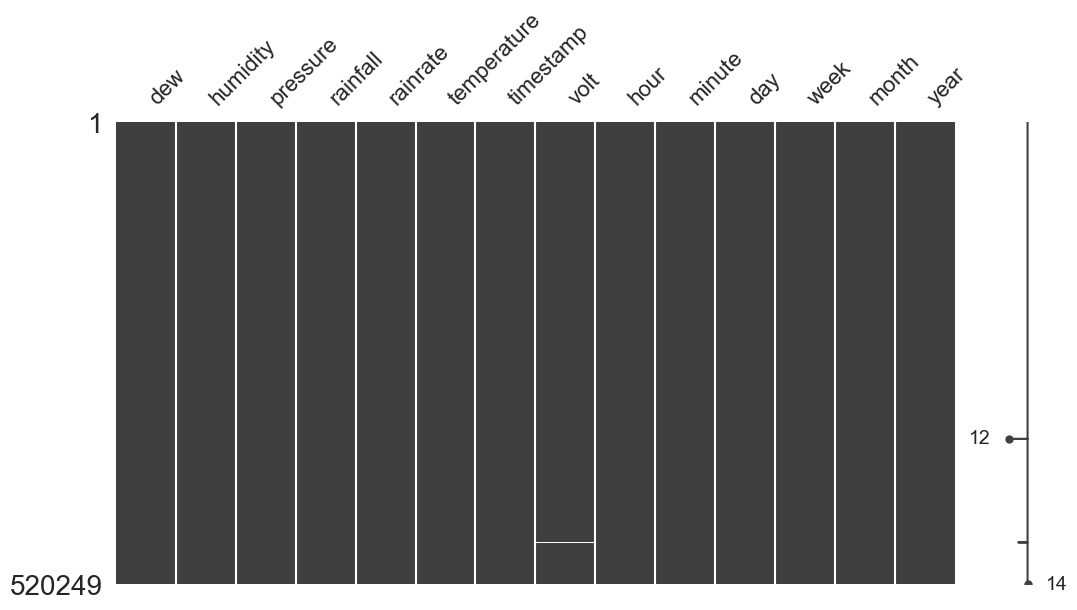


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 348

Contoh baris dengan null:
             dew  humidity  pressure  rainfall  rainrate  temperature  \
356864  23.99058     83.96  1013.427       NaN       NaN        26.94   
356865  23.85299     83.27  1013.431       NaN       NaN        26.94   
356866  23.83768     83.34  1013.452       NaN       NaN        26.91   
356867  23.90136     83.61  1013.442       NaN       NaN        26.92   
356868  23.88361     83.57  1013.464       NaN       NaN        26.91   
356869  23.92197     83.91  1013.455       NaN       NaN        26.88   
356870  23.95374     84.07  1013.456       NaN       NaN        26.88   
356871  24.02284     84.32  1013.469       NaN       NaN        26.90   
356872  24.01071     84.16  1013.480       NaN       NaN        26.92   
356873  23.98718     84.14  1013.476       NaN       NaN        26.90   

                       timestamp     volt  hour  minute  day  week  month  \
356864 2025-09-07 18:53:28+07

In [55]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca5 ===\n")
print(cuaca5.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca5.isnull().sum() / len(cuaca5)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca5, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca5[cuaca5.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_station_trends(data_dict, column_to_plot, freq='d', agg_method='mean'):
    """
    Membuat plot tren perbandingan dengan metode agregasi dinamis.

    Args:
        data_dict (dict): Dictionary {station_id: DataFrame}.
        column_to_plot (str): Nama kolom (misal: 'temperature', 'rain_mm').
        freq (str): 'd' (Harian), 'h' (Jam), 'min' (Menit).
        agg_method (str): Metode statistik ('mean', 'median', 'max', 'min', 'sum').
                          Default adalah 'mean'.
    """
    
    # 1. Konfigurasi Label Frekuensi
    freq_config = {
        'd': {'label': 'Harian', 'xlabel': 'Tanggal', 'code': 'd'}, # code: alias pandas
        'h': {'label': 'Per Jam', 'xlabel': 'Waktu (Jam)', 'code': 'h'},
        'min': {'label': 'Per Menit', 'xlabel': 'Waktu (Menit)', 'code': 'T'}
    }
    
    # Ambil config, default ke Harian jika typo
    selected_freq = freq_config.get(freq, freq_config['d'])
    
    # 2. Konfigurasi Label Agregasi (Biar judul grafik bahasa Indonesia)
    agg_labels = {
        'mean': 'Rata-rata',
        'median': 'Median (Nilai Tengah)',
        'max': 'Maksimum (Tertinggi)',
        'min': 'Minimum (Terendah)',
        'sum': 'Total Akumulasi'
    }
    # Ambil label indo, kalau gak ada pakai teks aslinya (misal 'std')
    agg_display_name = agg_labels.get(agg_method, agg_method.capitalize())

    # Mulai Plotting
    plt.figure(figsize=(15, 7))

    # Loop stasiun
    for station_id, df in data_dict.items():
        if column_to_plot not in df.columns:
            print(f"⚠️ Peringatan: Kolom '{column_to_plot}' tidak ada di {station_id}. Skip.")
            continue

        temp_df = df.copy()
        
        # Pastikan timestamp adalah datetime
        if not pd.api.types.is_datetime64_any_dtype(temp_df['timestamp']):
             temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

        # 3. PROSES GROUPING & AGREGASI DINAMIS
        # Kita buat kolom bantuan untuk grouping waktu
        time_col = f'time_group_{freq}'
        
        # dt.floor membulatkan waktu ke bawah (misal 13:45 -> 13:00 untuk jam)
        temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
        
        # INI BAGIAN KUNCI: .agg(agg_method) menggantikan .mean()
        # agg_method bisa berisi string: 'mean', 'sum', 'max', dll.
        trend_data = temp_df.groupby(time_col)[column_to_plot].agg(agg_method).reset_index()

        # Plotting
        plt.plot(trend_data[time_col], trend_data[column_to_plot], label=station_id, alpha=0.8)

    # 4. Mempercantik Visualisasi
    plt.xlabel(selected_freq['xlabel'], fontsize=12)
    plt.ylabel(f"{agg_display_name} {column_to_plot.replace('_', ' ').capitalize()}", fontsize=12)
    
    plt.title(f"Perbandingan {agg_display_name} {column_to_plot} ({selected_freq['label']})", 
              fontsize=14, fontweight='bold')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.show()

Menampilkan plot perbandingan per jam...


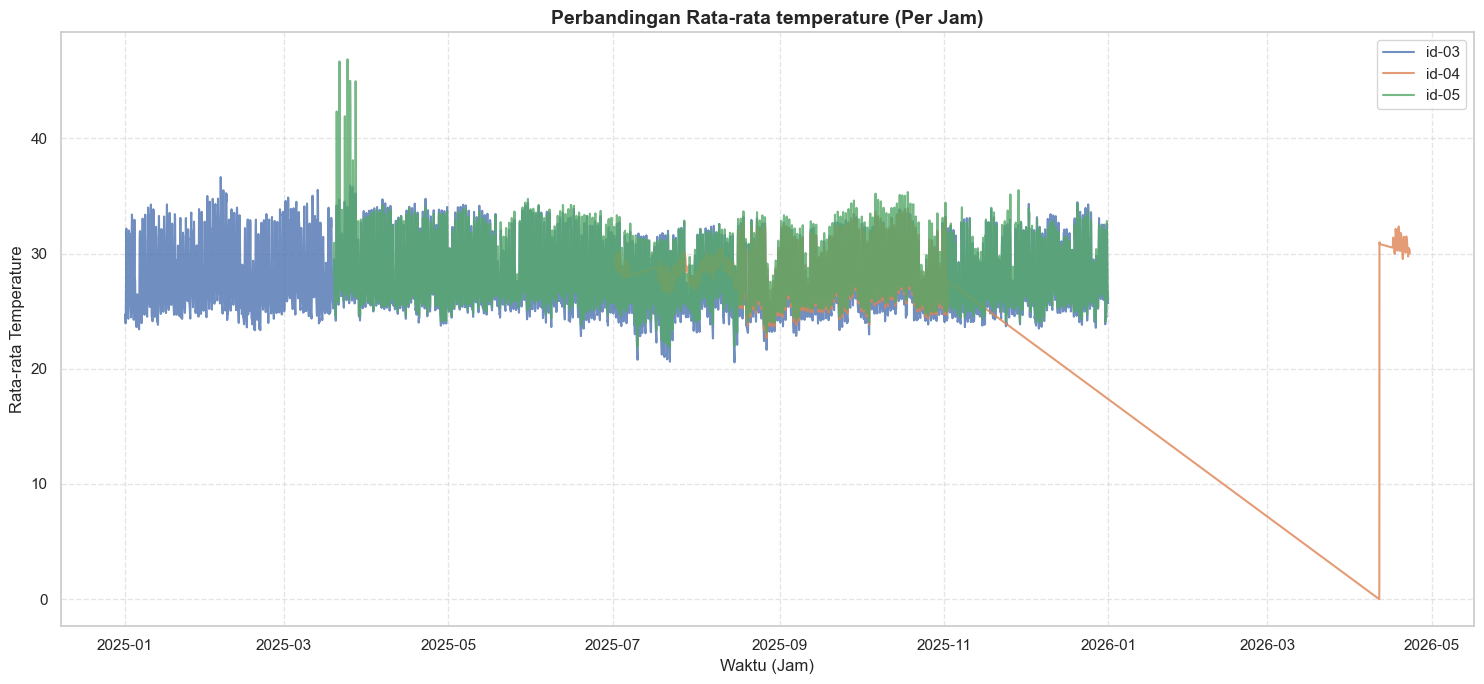

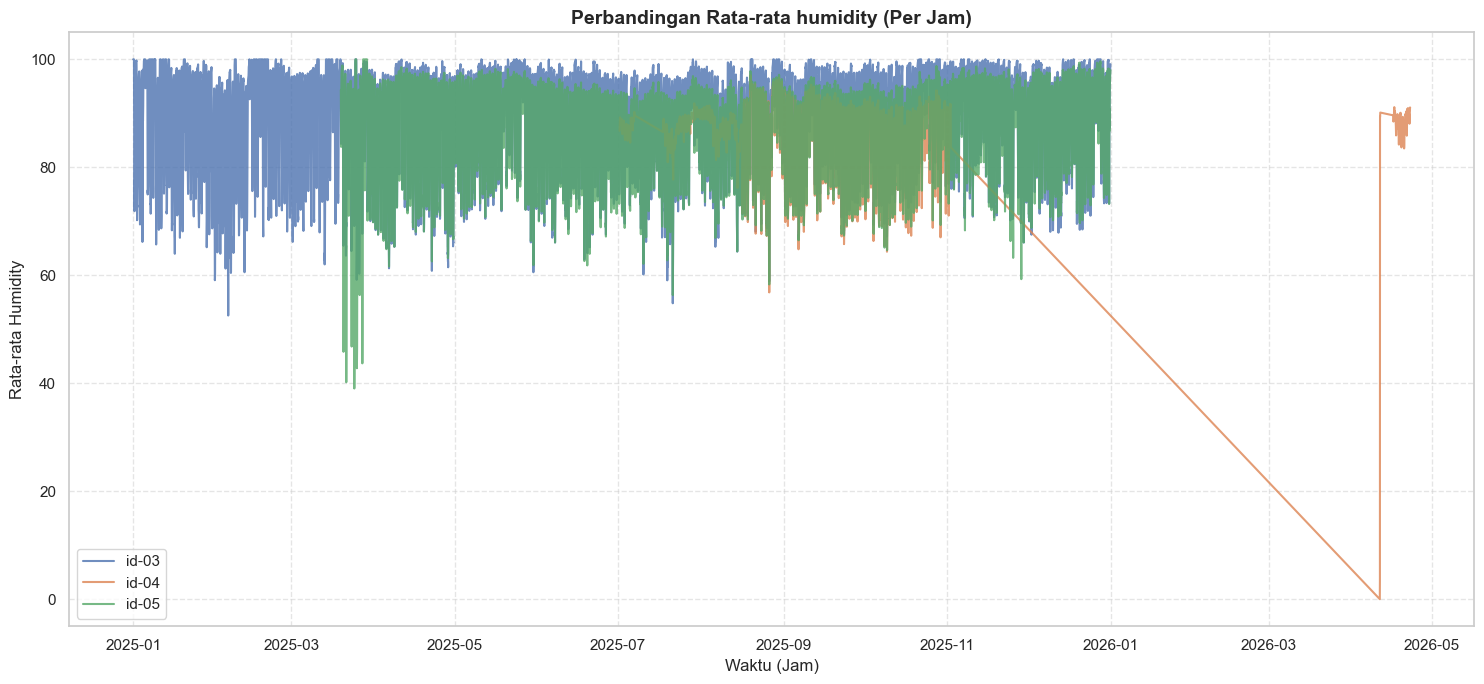

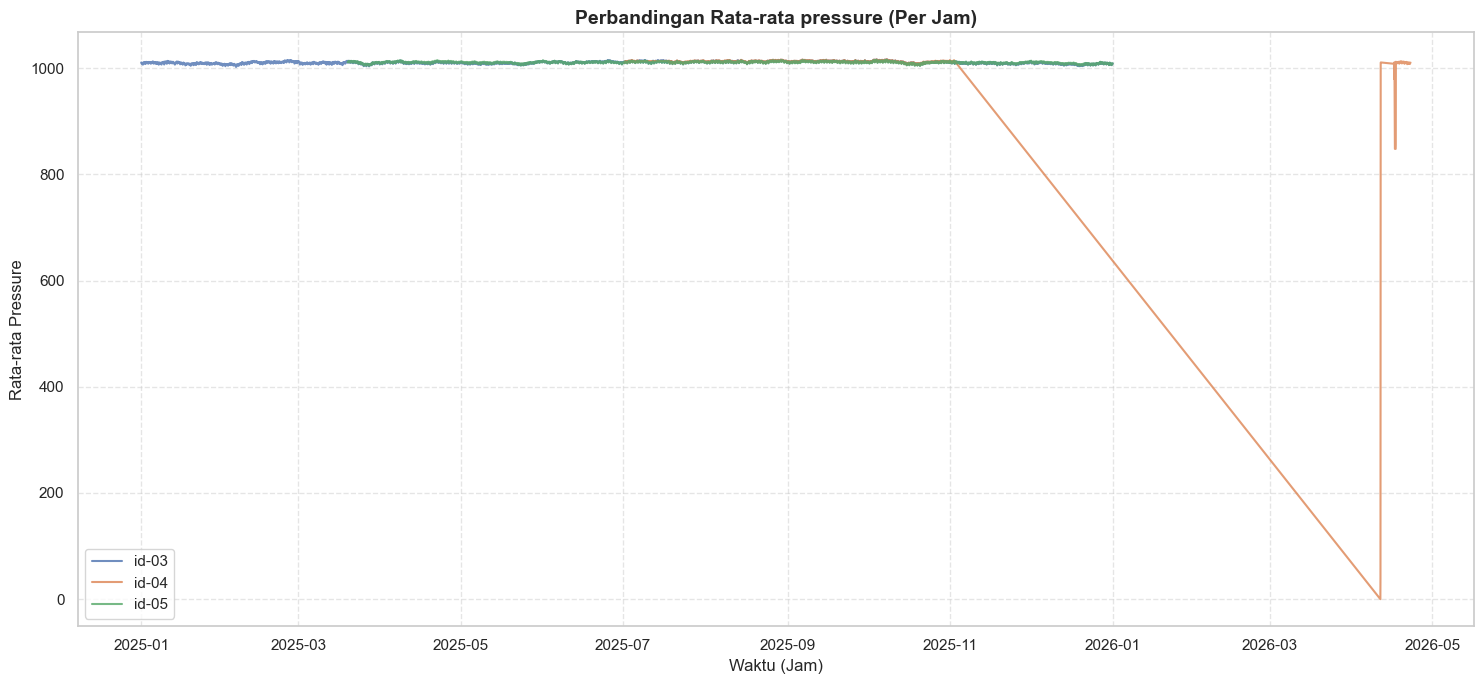

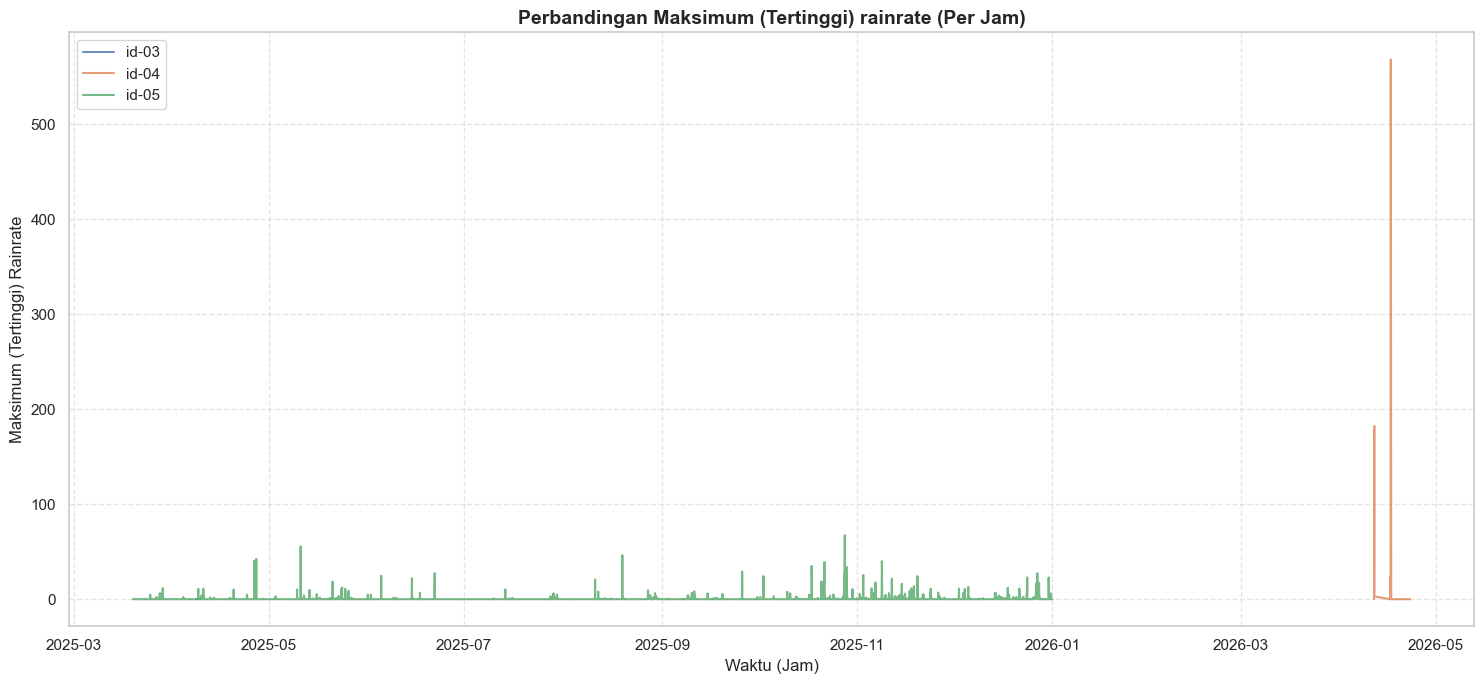

In [57]:
# --- 1. Membuat Plot Rata-rata PER JAM ---
# Cukup atur freq='h'
print("Menampilkan plot perbandingan per jam...")
plot_station_trends(weather_dataframes, 'temperature', freq='h', agg_method='mean')
plot_station_trends(weather_dataframes, 'humidity', freq='h', agg_method='mean')
plot_station_trends(weather_dataframes, 'pressure', freq='h', agg_method='mean')
plot_station_trends(weather_dataframes, 'rainrate', freq='h', agg_method='max')


Menampilkan plot perbandingan per hari...


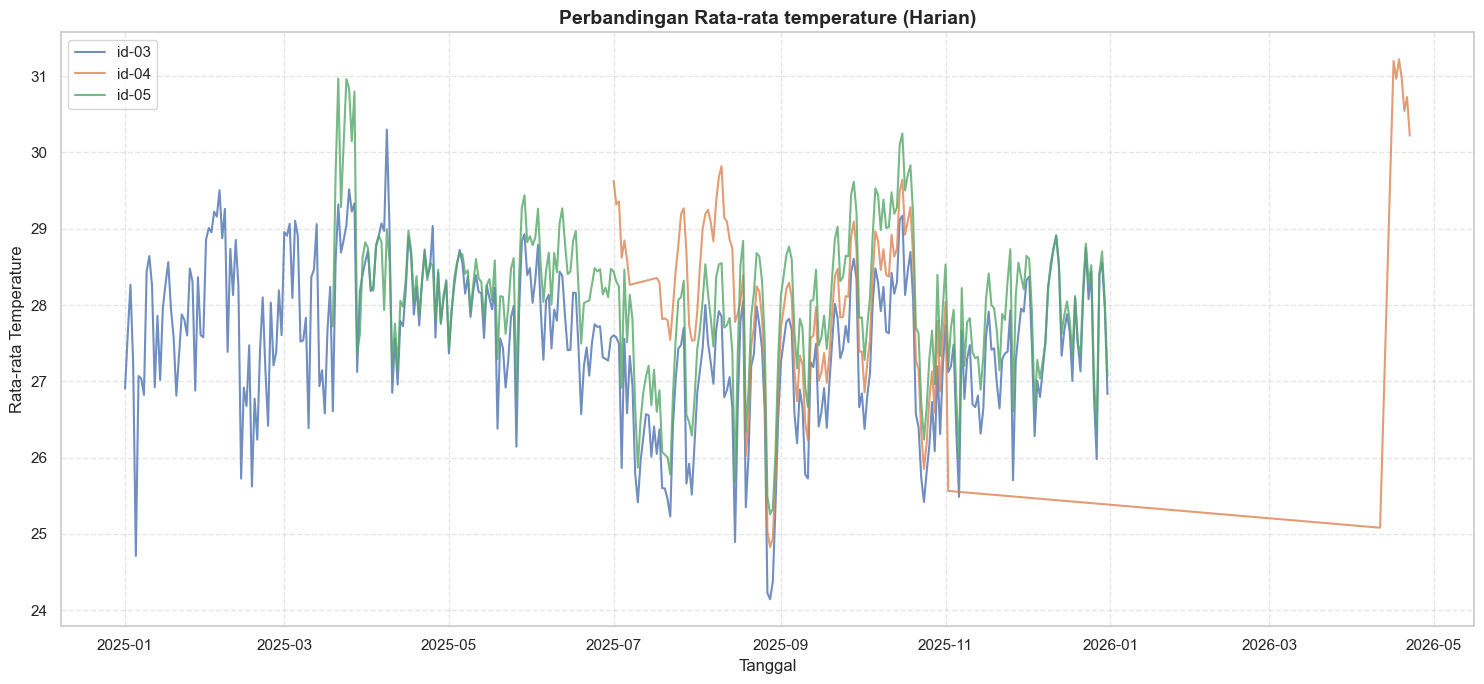

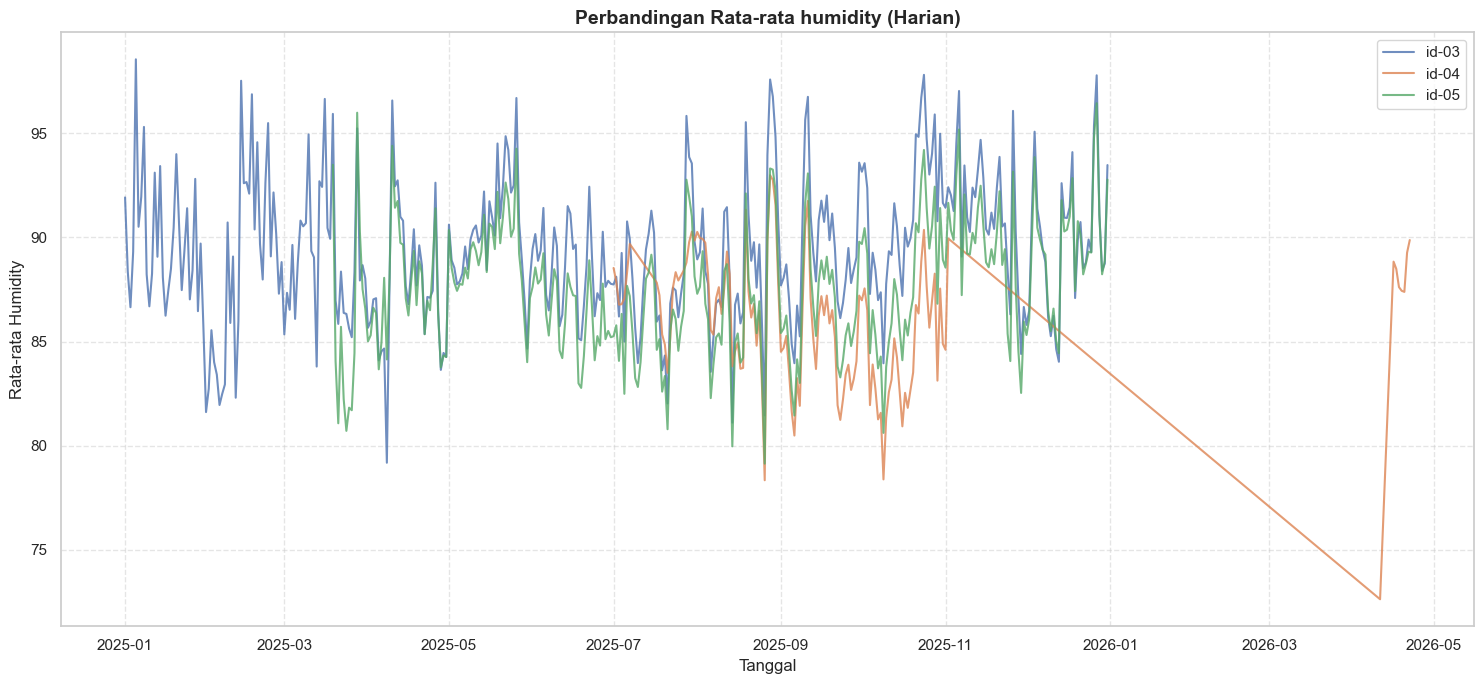

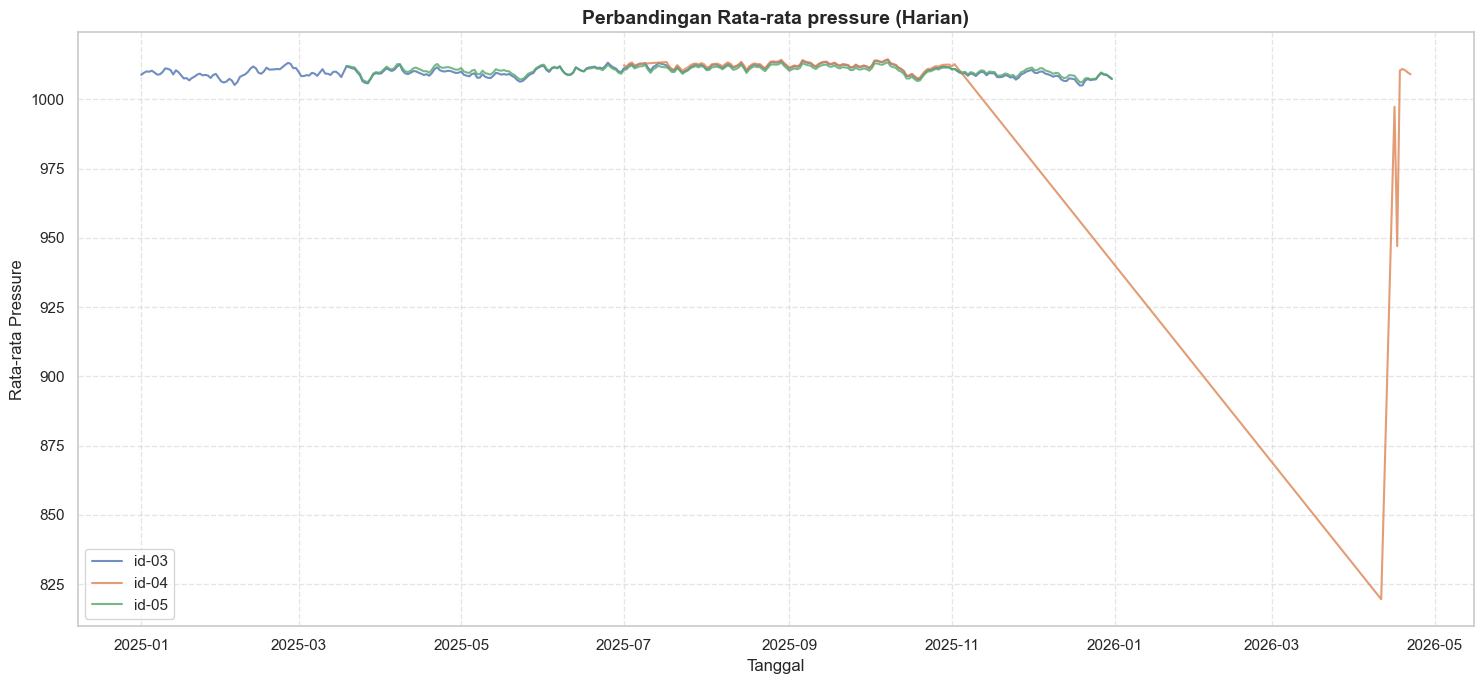

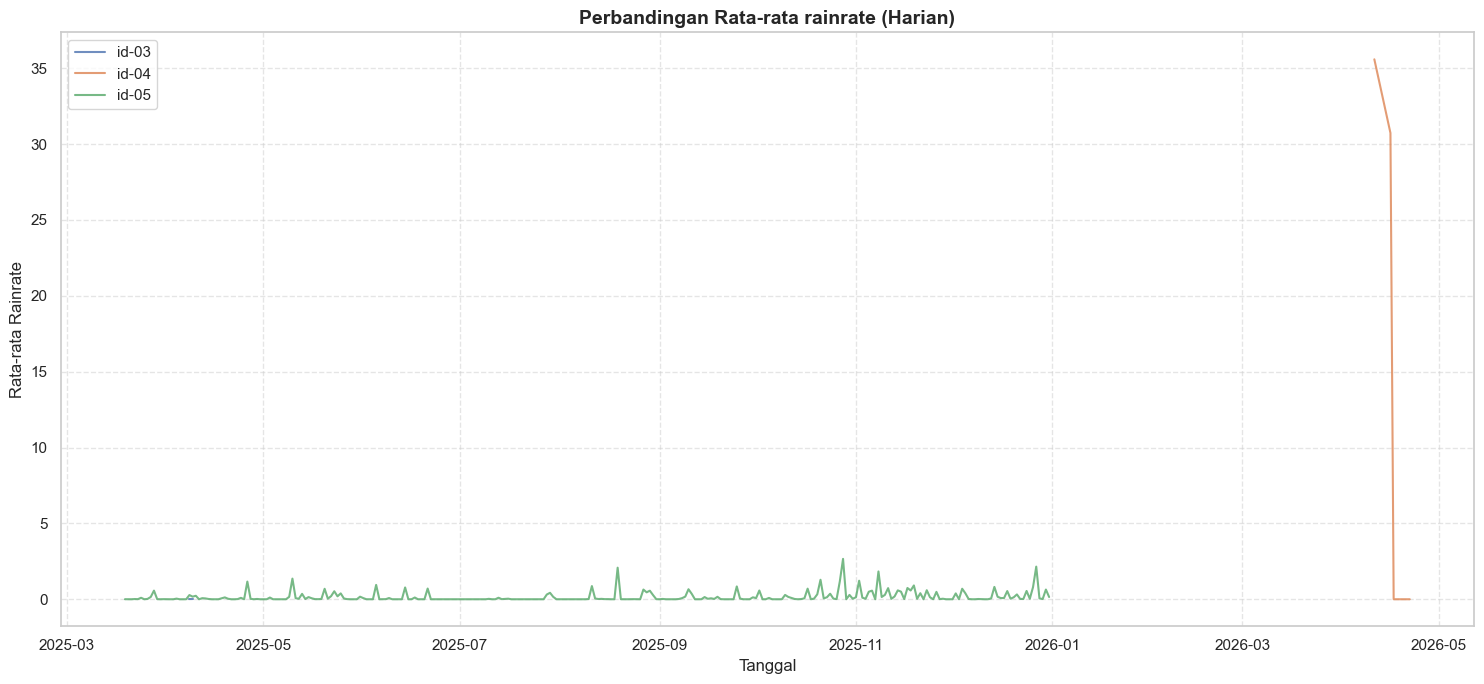

In [58]:
# --- 2. Membuat Plot Rata-rata PER HARI ---
# Gunakan nilai default freq='d' atau tulis secara eksplisit
print("\nMenampilkan plot perbandingan per hari...")
plot_station_trends(weather_dataframes, 'temperature', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'humidity', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'pressure', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'rainrate', freq='d', agg_method='mean')

C:\Users\acer\AppData\Local\Temp\ipykernel_3736\3262811711.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
C:\Users\acer\AppData\Local\Temp\ipykernel_3736\3262811711.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
C:\Users\acer\AppData\Local\Temp\ipykernel_3736\3262811711.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])


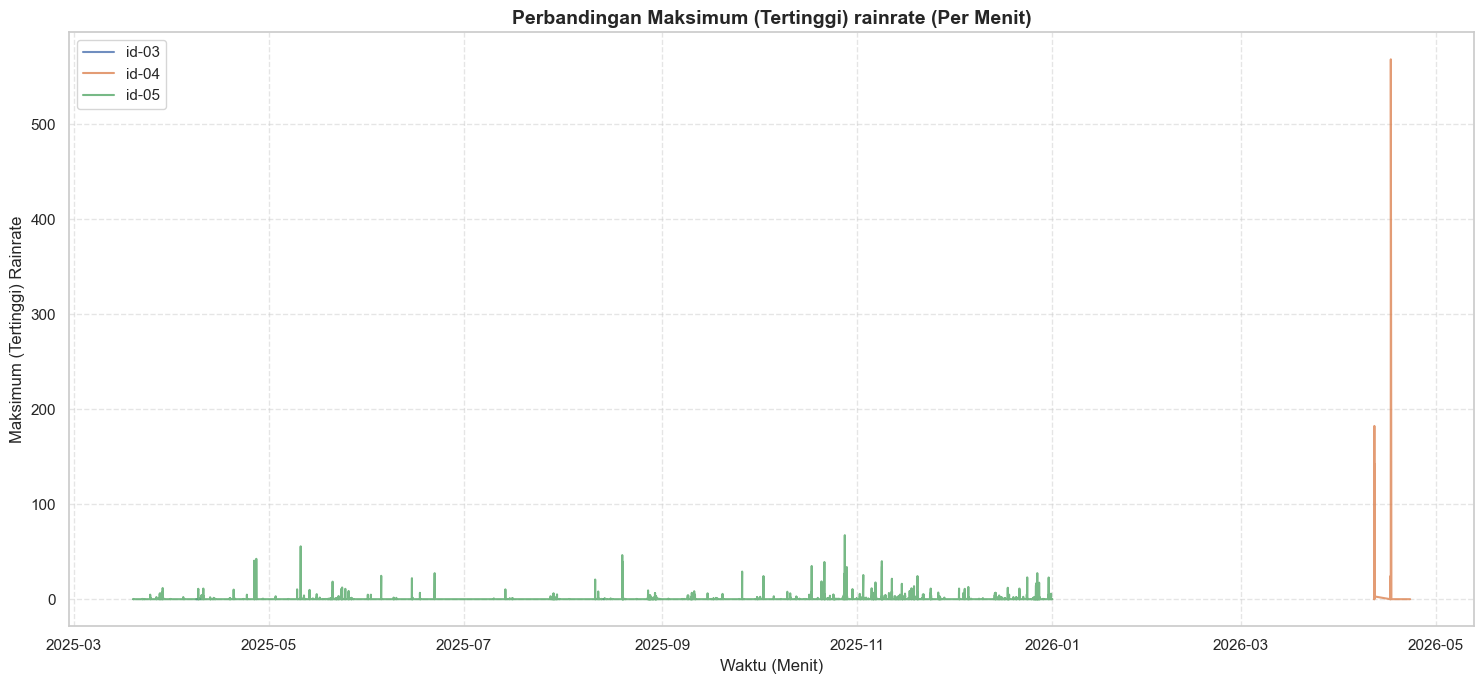

In [59]:
plot_station_trends(weather_dataframes, 'rainrate', freq='min', agg_method='max')

--- PENGUJIAN KONSTANTA: 0.2794 mm/tip ---
Rata-rata penyimpangan dari bilangan bulat: 0.0153


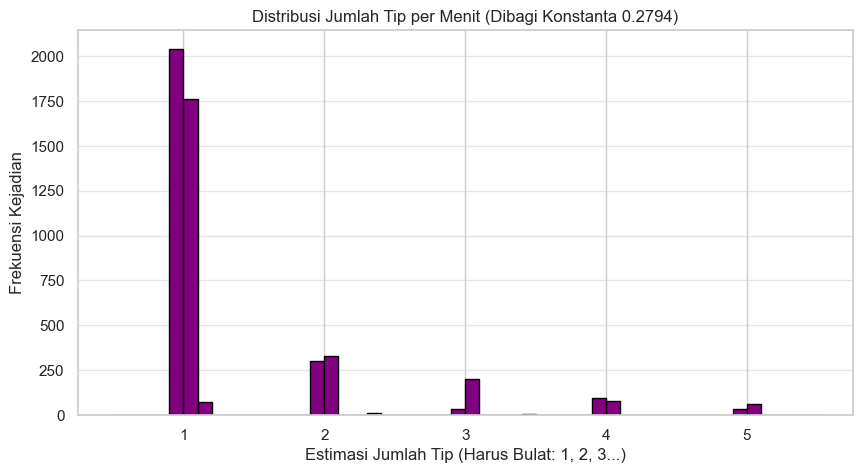

In [60]:
# Pastikan data urut waktu
cuaca5 = cuaca5.sort_values('timestamp').reset_index(drop=True)

# 1. HITUNG DELTA (Hujan per menit/interval)
# Kita gunakan .diff() untuk mencari selisih dari baris sebelumnya
cuaca5['delta_rain'] = cuaca5['rainfall'].diff()

# Bersihkan nilai negatif (anggap 0 karena itu reset/noise turun)
cuaca5['delta_rain'] = cuaca5['delta_rain'].clip(lower=0)

# 2. TENTUKAN KONSTANTA (Coba salah satu yang Anda sebutkan)
# Silakan ganti angka ini: 0.2, 0.2794, atau 0.32125
KONSTANTA_TIP = 0.2794  # <-- Ganti sesuai spesifikasi alat Anda!

# 3. HITUNG JUMLAH TIP (ESTIMASI)
cuaca5['estimated_tips'] = cuaca5['delta_rain'] / KONSTANTA_TIP

# 4. CEK APAKAH HASILNYA BULAT? (VALIDASI)
# Kita ambil hanya data yang hujannya > 0
data_hujan = cuaca5[cuaca5['delta_rain'] > 0].copy()

# Hitung sisa pembagian (Residual) dari bilangan bulat terdekat
# Contoh: Jika hasil 1.01 -> sisa 0.01 (Bagus)
#         Jika hasil 1.50 -> sisa 0.50 (Jelek/Salah Konstanta)
data_hujan['jarak_ke_bulat'] = np.abs(data_hujan['estimated_tips'] - np.round(data_hujan['estimated_tips']))

print(f"--- PENGUJIAN KONSTANTA: {KONSTANTA_TIP} mm/tip ---")
print(f"Rata-rata penyimpangan dari bilangan bulat: {data_hujan['jarak_ke_bulat'].mean():.4f}")

# 5. VISUALISASI HISTOGRAM TIP
# Jika konstantanya BENAR, grafik akan menumpuk di angka 1.0, 2.0, 3.0
# Jika konstantanya SALAH, grafik akan menyebar acak
plt.figure(figsize=(10, 5))
plt.hist(data_hujan['estimated_tips'], bins=50, range=(0.5, 5.5), color='purple', edgecolor='black')
plt.title(f'Distribusi Jumlah Tip per Menit (Dibagi Konstanta {KONSTANTA_TIP})')
plt.xlabel('Estimasi Jumlah Tip (Harus Bulat: 1, 2, 3...)')
plt.ylabel('Frekuensi Kejadian')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.5)
plt.show()

In [61]:
data_hujan.tail(100)

,dew,humidity,pressure,rainfall,rainrate,temperature,timestamp,volt,hour,minute,day,week,month,year,delta_rain,estimated_tips,jarak_ke_bulat
518640,23.79633,98.36790,1010.14,13.1815,13.1815,24.07072,2025-12-30 20:13:16+07:00,3.93750,20,13,30,1,12,2025,0.9645,3.452040,0.452040
518641,23.83197,98.61013,1010.11,14.1460,14.1460,24.06538,2025-12-30 20:14:16+07:00,3.93125,20,14,30,1,12,2025,0.9645,3.452040,0.452040
518642,23.72107,98.36408,1010.03,15.1105,15.1105,23.99596,2025-12-30 20:15:16+07:00,3.95750,20,15,30,1,12,2025,0.9645,3.452040,0.452040
518643,23.75886,98.33547,1009.95,16.3965,16.3965,24.03868,2025-12-30 20:16:16+07:00,3.92375,20,16,30,1,12,2025,1.2860,4.602720,0.397280
518644,23.77039,98.48234,1009.90,17.3610,17.3610,24.02533,2025-12-30 20:17:16+07:00,3.96375,20,17,30,1,12,2025,0.9645,3.452040,0.452040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519557,27.43830,71.56542,1007.14,34.0790,0.0000,33.29404,2025-12-31 11:34:19+07:00,3.93875,11,34,31,1,12,2025,32.7680,117.279885,0.279885
519657,27.27865,90.41413,1005.93,39.2230,5.1440,29.01350,2025-12-31 13:51:00+07:00,3.92125,13,51,31,1,12,2025,5.1440,18.410880,0.410880
519660,26.99447,92.97002,1005.83,39.5445,5.4655,28.24445,2025-12-31 13:54:00+07:00,3.96500,13,54,31,1,12,2025,0.3215,1.150680,0.150680
519663,27.22716,93.56130,1005.69,39.8660,5.7870,28.36996,2025-12-31 13:58:05+07:00,3.94125,13,58,31,1,12,2025,0.3215,1.150680,0.150680


In [62]:
cuaca5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520249 entries, 0 to 520248
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype                       
---  ------          --------------   -----                       
 0   dew             520249 non-null  float64                     
 1   humidity        520249 non-null  float64                     
 2   pressure        520249 non-null  float64                     
 3   rainfall        520178 non-null  float64                     
 4   rainrate        520178 non-null  float64                     
 5   temperature     520249 non-null  float64                     
 6   timestamp       520249 non-null  datetime64[ns, Asia/Jakarta]
 7   volt            519972 non-null  float64                     
 8   hour            520249 non-null  int32                       
 9   minute          520249 non-null  int32                       
 10  day             520249 non-null  int32                       
 11  week         

In [74]:
import pandas as pd
import numpy as np

# 1. PERSIAPAN
df_proses = cuaca5.copy()
if 'timestamp' in df_proses.columns:
    df_proses = df_proses.set_index('timestamp')
df_proses = df_proses.sort_index()

# ==========================================
# 2. SETRIKA DATA (MEMBERSIHKAN GLITCH TURUN)
# ==========================================
# Kita buat kolom baru agar data asli tidak rusak
df_proses['rainfall_clean'] = df_proses['rainfall'].copy()
delta_kotor = df_proses['rainfall'].diff()

# Logika Emas: Jika data tiba-tiba turun (delta < 0), 
# TAPI angkanya tidak jatuh ke angka kecil (misal masih > 0.5 mm), 
# itu PASTI noise/glitch (Poin 1 Anda), BUKAN reset.
mask_glitch_turun = (delta_kotor < 0) & (df_proses['rainfall'] > 0.5)

# Jadikan NaN, lalu "Setrika" (Forward Fill) dengan nilai menit sebelumnya
df_proses.loc[mask_glitch_turun, 'rainfall_clean'] = np.nan
df_proses['rainfall_clean'] = df_proses['rainfall_clean'].ffill()

# ==========================================
# 3. HITUNG SELISIH DARI DATA YANG SUDAH BERSIH
# ==========================================
df_proses['rain_actual_minute'] = df_proses['rainfall_clean'].diff()

# ==========================================
# 4. FIX RESET ASLI (Poin 2 Anda)
# ==========================================
# Karena glitch sudah disetrika di langkah 2, 
# jika sekarang masih ada delta < 0, itu 100% adalah Reset Asli (Jatuh ke 0).
mask_reset_asli = df_proses['rain_actual_minute'] < 0

# Hujan murni tepat di menit reset itu adalah sisa air di ember saat itu
df_proses.loc[mask_reset_asli, 'rain_actual_minute'] = df_proses.loc[mask_reset_asli, 'rainfall_clean']

# ==========================================
# 5. FIX LONJAKAN KE ATAS (GLITCH NAIK)
# ==========================================
BATAS_MAKSIMAL_PER_MENIT = 10.0  # mm
mask_ngawur = df_proses['rain_actual_minute'] > BATAS_MAKSIMAL_PER_MENIT
df_proses.loc[mask_ngawur, 'rain_actual_minute'] = 0 

# Bersihkan sisa NaN di baris paling pertama
df_proses['rain_actual_minute'] = df_proses['rain_actual_minute'].fillna(0)
# Pastikan mutlak tidak ada angka minus
df_proses['rain_actual_minute'] = df_proses['rain_actual_minute'].clip(lower=0)

# ==========================================
# 6. RESAMPLE KE JAM (Poin 4 Anda)
# ==========================================
# Sekarang kita BISA MENGGUNAKAN SUM DENGAN AMAN!
agg_rules = {
    'rain_actual_minute': 'sum', 
    'temperature': 'mean',
    'humidity': 'mean',
    'pressure': 'mean',
    'dew': 'mean'
}

df_hourly = df_proses.resample('1h').agg(agg_rules)
df_hourly = df_hourly.rename(columns={'rain_actual_minute': 'rain_mm'})

# Cek apakah angka 70 mm gaib itu sudah hilang
print(f"\nMax Hujan per Jam (Setelah Di-Setrika): {df_hourly['rain_mm'].max():.2f} mm")


Max Hujan per Jam (Setelah Di-Setrika): 59.23 mm


In [75]:
df_hourly.tail(100)

,rain_mm,temperature,humidity,pressure,dew
timestamp,,,,,
2025-12-27 20:00:00+07:00,17.0434,26.164708,98.853641,1010.674833,25.969241
2025-12-27 21:00:00+07:00,0.0000,25.990874,98.782637,1011.035593,25.783536
2025-12-27 22:00:00+07:00,1.6075,25.944586,98.988047,1010.877667,25.772466
2025-12-27 23:00:00+07:00,0.0000,25.761757,98.596463,1010.303667,25.522961
2025-12-28 00:00:00+07:00,0.3215,25.583466,98.945195,1009.482667,25.404502
...,...,...,...,...,...
2025-12-31 19:00:00+07:00,0.0000,26.402602,96.300458,1008.066271,25.763572
2025-12-31 20:00:00+07:00,0.0000,26.199820,96.875624,1008.194912,25.662399
2025-12-31 21:00:00+07:00,7.0730,26.082282,97.353297,1008.593167,25.628387


C:\Users\acer\AppData\Local\Temp\ipykernel_3736\1737085646.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


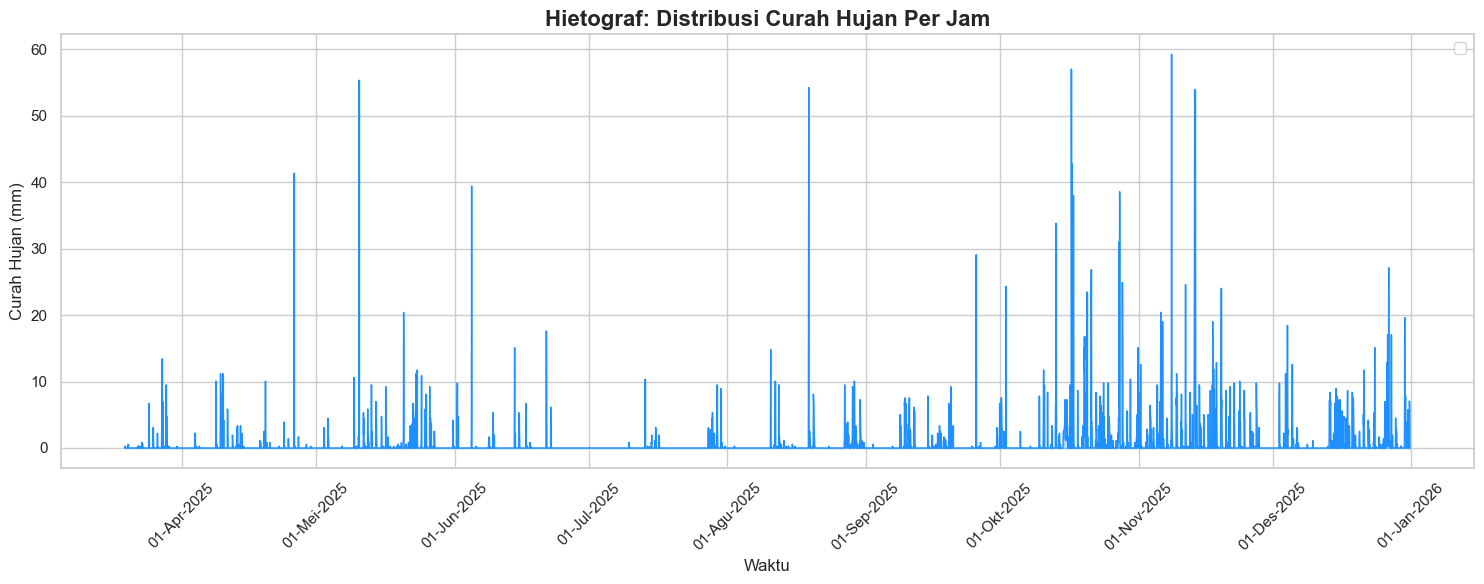

In [85]:
# Set Style biar ganteng
sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# A. PLOT DATA
# Kita pakai bar plot, tapi karena indexnya datetime, kita atur width-nya
# Width 0.03 hari (sekitar 45 menit) biar ada celah dikit antar jam
#plt.bar(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', width=1, label='Curah Hujan (mm/jam)')

# Alternatif kalau data sangat padat (tahunan), pakai ini:
plt.plot(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', lw=1)
plt.fill_between(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', alpha=0.3)

# B. PERCANTIK
plt.title('Hietograf: Distribusi Curah Hujan Per Jam', fontsize=16, fontweight='bold')
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.xlabel('Waktu', fontsize=12)
plt.legend(loc='upper right')

# Format Tanggal di Sumbu X biar rapi
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Label per bulan
plt.xticks(rotation=45)

# Batas Y (opsional, biar kelihatan ruang atasnya)
# plt.ylim(0, df_hourly['rain_mm'].max() * 1.2) 

plt.tight_layout()
plt.show()

In [77]:
waktu_puncak = df_hourly['rain_mm'].idxmax()
nilai_puncak = df_hourly['rain_mm'].max()

print(f"Hujan terderas terjadi pada: {waktu_puncak}")
print(f"Sebesar: {nilai_puncak} mm")

Hujan terderas terjadi pada: 2025-11-08 16:00:00+07:00
Sebesar: 59.232800000000005 mm


In [78]:
# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
PATH_FILE_DESA = 'D:\Github\Catatan_Meteorologi\Analisis_Meteorologi\open_meteo_jerukagung\cuaca_jerukagung.csv'
PATH_FILE_KOTA = 'D:\Github\Catatan_Meteorologi\Analisis_Meteorologi\open_meteo_kebumen\cuaca_kebumen.csv'

In [79]:
def load_data(filepath):
    if not os.path.exists(filepath):
        print(f"❌ File tidak ditemukan: {filepath}")
        return None
    try:
        df = pd.read_csv(filepath, index_col='date')
        df.index = pd.to_datetime(df.index, utc=True, errors='coerce')
        df.index = df.index.tz_convert('Asia/Jakarta')
        df.index = df.index.tz_localize(None)
        df = df.sort_index()
        return df
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

In [80]:
# 1. Load semua data dulu
df_desa = load_data(PATH_FILE_DESA)

# ==============================================================================
# 🛠️ TAHAP 1: PERSIAPAN SLICING (Jadikan Naive Sementara)
# ==============================================================================
# Kita ubah dulu ke waktu Jakarta, lalu "copot" labelnya sementara.
# Tujuannya: Agar sintaks slicing .loc['2025'] berjalan mulus tanpa error.

if df_desa.index.tz is not None:
    # 1. Pastikan jamnya sudah digeser ke WIB (+07:00)
    df_desa.index = df_desa.index.tz_convert('Asia/Jakarta')
    
    # 2. HAPUS label zona waktunya sementara
    # Jam 07:00 WIB (+7) akan menjadi jam 07:00 (Polos)
    df_desa.index = df_desa.index.tz_localize(None)

print("Index sementara dikonversi ke Naive (untuk filtering).")

# ==============================================================================
# 🛠️ TAHAP 2: FILTERING & RE-LOCALIZATION (Pasang Lagi Zonanya)
# ==============================================================================

# 1. Ambil data tahun 2025
df_desa = df_desa.loc['2025':'2026'].copy()

# 2. PASANG KEMBALI ZONA WAKTU ASIA/JAKARTA 
# Karena tadi kita sudah pastikan jamnya benar (langkah Tahap 1.1),
# kita tinggal tempel label 'Asia/Jakarta' lagi.
df_desa.index = df_desa.index.tz_localize('Asia/Jakarta')

print("\n" + "="*40)
print("FILTER BERHASIL & ZONA WAKTU TERPASANG")
print("="*40)
print(f"Zona Waktu: {df_desa.index.tz}") # Harus muncul Asia/Jakarta
print(f"Start     : {df_desa.index.min()}")
print(f"End       : {df_desa.index.max()}")
print(f"Total     : {len(df_desa)} baris")

# Tampilkan data akhir
df_desa.tail(10)

Index sementara dikonversi ke Naive (untuk filtering).

FILTER BERHASIL & ZONA WAKTU TERPASANG
Zona Waktu: Asia/Jakarta
Start     : 2025-01-01 00:00:00+07:00
End       : 2026-05-01 23:00:00+07:00
Total     : 11664 baris


,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2026-05-01 14:00:00+07:00,29.60,72.580440,24.15,0.2,15.626860,155.501430,1006.44037,3600.00000,34.0,51.0
2026-05-01 15:00:00+07:00,29.10,74.706116,24.15,0.5,15.735336,144.309840,1005.83826,3600.00000,42.0,53.0
2026-05-01 16:00:00+07:00,28.80,75.560265,24.05,0.4,14.764390,135.000100,1005.83594,3600.00000,33.0,51.0
2026-05-01 17:00:00+07:00,28.30,78.020340,24.10,0.1,14.336861,128.884500,1006.23140,3600.00000,30.0,51.0
2026-05-01 18:00:00+07:00,28.05,77.051285,23.65,0.0,11.594292,117.758450,1006.62885,299.61163,26.0,1.0
2026-05-01 19:00:00+07:00,28.20,76.611230,23.70,0.1,11.734564,122.471176,1006.82940,0.00000,23.0,51.0
2026-05-01 20:00:00+07:00,28.00,77.509224,23.70,0.1,12.730468,123.465400,1007.42690,0.00000,25.0,51.0
2026-05-01 21:00:00+07:00,27.50,79.806560,23.70,0.2,9.473541,104.300316,1007.92194,0.00000,48.0,51.0
2026-05-01 22:00:00+07:00,26.85,84.671790,24.05,0.3,10.435344,104.995130,1008.41620,0.00000,73.0,51.0


In [81]:
# 1. Load semua data dulu
df_kota = load_data(PATH_FILE_KOTA)

# ==============================================================================
# 🛠️ TAHAP 1: PERSIAPAN SLICING (Jadikan Naive Sementara)
# ==============================================================================
# Kita ubah dulu ke waktu Jakarta, lalu "copot" labelnya sementara.
# Tujuannya: Agar sintaks slicing .loc['2025'] berjalan mulus tanpa error.

if df_kota.index.tz is not None:
    # 1. Pastikan jamnya sudah digeser ke WIB (+07:00)
    df_kota.index = df_kota.index.tz_convert('Asia/Jakarta')
    
    # 2. HAPUS label zona waktunya sementara
    # Jam 07:00 WIB (+7) akan menjadi jam 07:00 (Polos)
    df_kota.index = df_kota.index.tz_localize(None)

print("✅ Index sementara dikonversi ke Naive (untuk filtering).")

# ==============================================================================
# 🛠️ TAHAP 2: FILTERING & RE-LOCALIZATION (Pasang Lagi Zonanya)
# ==============================================================================

# 1. Ambil data tahun
df_kota= df_kota.loc['2025':'2026'].copy()

# 2. 🚨 PASANG KEMBALI ZONA WAKTU ASIA/JAKARTA 🚨
# Karena tadi kita sudah pastikan jamnya benar (langkah Tahap 1.1),
# kita tinggal tempel label 'Asia/Jakarta' lagi.
df_kota.index = df_kota.index.tz_localize('Asia/Jakarta')

print("\n" + "="*40)
print("✅ FILTER BERHASIL & ZONA WAKTU TERPASANG")
print("="*40)
print(f"Zona Waktu: {df_kota.index.tz}") # Harus muncul Asia/Jakarta
print(f"Start     : {df_kota.index.min()}")
print(f"End       : {df_kota.index.max()}")
print(f"Total     : {len(df_kota)} baris")

# Tampilkan data akhir
df_kota.tail(10)

✅ Index sementara dikonversi ke Naive (untuk filtering).

✅ FILTER BERHASIL & ZONA WAKTU TERPASANG
Zona Waktu: Asia/Jakarta
Start     : 2025-01-01 00:00:00+07:00
End       : 2026-05-01 23:00:00+07:00
Total     : 11664 baris


,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2026-05-01 14:00:00+07:00,30.25,68.463340,23.80,0.0,14.784126,132.03899,1005.87870,3600.00000,42.0,1.0
2026-05-01 15:00:00+07:00,28.95,72.686840,23.55,0.1,14.186923,125.70678,1005.36835,3600.00000,39.0,51.0
2026-05-01 16:00:00+07:00,28.65,74.633286,23.70,0.1,13.159710,130.00620,1005.36560,3600.00000,28.0,51.0
2026-05-01 17:00:00+07:00,27.80,79.368330,23.90,0.1,9.446141,120.96369,1005.75690,3600.00000,23.0,51.0
2026-05-01 18:00:00+07:00,26.85,82.659330,23.65,0.0,6.479999,90.00000,1006.24670,304.21408,18.0,0.0
2026-05-01 19:00:00+07:00,26.80,84.666590,24.00,0.0,5.762812,88.21013,1006.44590,0.00000,27.0,1.0
2026-05-01 20:00:00+07:00,26.85,83.660280,23.85,0.0,7.208994,92.86235,1006.94480,0.00000,19.0,0.0
2026-05-01 21:00:00+07:00,26.30,85.897865,23.75,0.1,5.762812,88.21013,1007.43840,0.00000,32.0,51.0
2026-05-01 22:00:00+07:00,25.80,88.210686,23.70,0.1,5.119727,100.12462,1007.83280,0.00000,38.0,51.0


In [82]:
df_hourly.tail(100)

,rain_mm,temperature,humidity,pressure,dew
timestamp,,,,,
2025-12-27 20:00:00+07:00,17.0434,26.164708,98.853641,1010.674833,25.969241
2025-12-27 21:00:00+07:00,0.0000,25.990874,98.782637,1011.035593,25.783536
2025-12-27 22:00:00+07:00,1.6075,25.944586,98.988047,1010.877667,25.772466
2025-12-27 23:00:00+07:00,0.0000,25.761757,98.596463,1010.303667,25.522961
2025-12-28 00:00:00+07:00,0.3215,25.583466,98.945195,1009.482667,25.404502
...,...,...,...,...,...
2025-12-31 19:00:00+07:00,0.0000,26.402602,96.300458,1008.066271,25.763572
2025-12-31 20:00:00+07:00,0.0000,26.199820,96.875624,1008.194912,25.662399
2025-12-31 21:00:00+07:00,7.0730,26.082282,97.353297,1008.593167,25.628387


✅ Data yang siap dibandingkan: 6899 jam

📊 HASIL KORELASI:
   - Pearson (Linear)   : 0.1319
   - Spearman (Ranking) : 0.2637


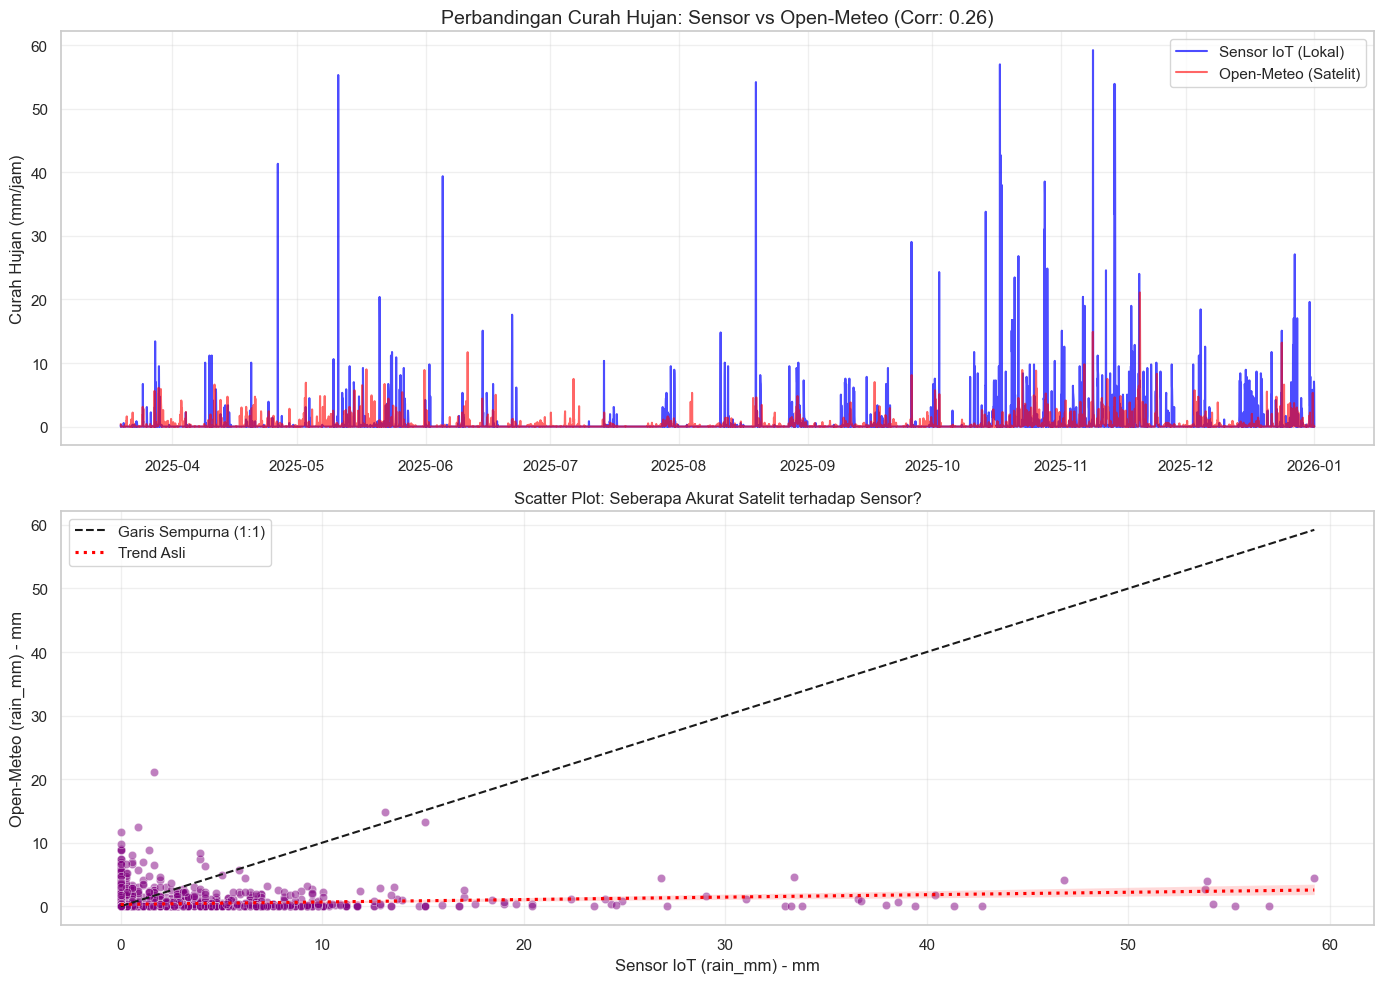

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# ==============================================================================
# 1. PERSIAPAN DATA (ALIGNMENT)
# ==============================================================================

# Asumsi nama variabel kamu
df_sensor = df_hourly
df_open_meteo = df_desa

# Pastikan nama kolom hujan sama biar enak
col_sensor = 'rain_mm'
# Cek nama kolom di open meteo, biasanya 'rain' atau 'precipitation'
col_satelit = 'rain_mm' if 'rain_mm' in df_open_meteo.columns else 'precipitation'

# GABUNGKAN DATA BERDASARKAN WAKTU (INTERSECTION)
# Inner Join: Hanya ambil jam dimana KEDUANYA punya data
df_compare = pd.merge(df_hourly[[col_sensor]], 
                      df_open_meteo[[col_satelit]], 
                      left_index=True, 
                      right_index=True, 
                      suffixes=('_sensor', '_satelit'))

# Hapus baris yang ada NaN (kalau ada bolong dikit)
df_compare = df_compare.dropna()

print(f"✅ Data yang siap dibandingkan: {len(df_compare)} jam")

# ==============================================================================
# 2. HITUNG KORELASI
# ==============================================================================
x = df_compare[f'{col_sensor}_sensor']
y = df_compare[f'{col_satelit}_satelit']

# Pearson (Linear - Seberapa lurus hubungannya)
corr_p = x.corr(y, method='pearson')

# Spearman (Rank - Seberapa konsisten polanya, cocok buat hujan)
corr_s, _ = spearmanr(x, y)

print("\n📊 HASIL KORELASI:")
print(f"   - Pearson (Linear)   : {corr_p:.4f}")
print(f"   - Spearman (Ranking) : {corr_s:.4f}")

# ==============================================================================
# 3. VISUALISASI
# ==============================================================================
plt.figure(figsize=(14, 10))

# --- PLOT 1: TIME SERIES (Grafik Garis) ---
plt.subplot(2, 1, 1)
# Ambil sampel 1 minggu terakhir atau periode hujan lebat biar jelas (opsional)
# df_plot = df_compare.iloc[-168:] # 168 jam = 1 minggu
df_plot = df_compare # Plot semua (hati-hati kalau datanya panjang banget jadi ruwet)

plt.plot(df_plot.index, df_plot[f'{col_sensor}_sensor'], 
         label='Sensor IoT (Lokal)', 
         color='blue', 
         alpha=0.7, 
         linewidth=1.5)
plt.plot(df_plot.index, df_plot[f'{col_satelit}_satelit'], 
         label='Open-Meteo (Satelit)', 
         color='red', 
         alpha=0.6,
         linewidth=1.5)

plt.title(f'Perbandingan Curah Hujan: Sensor vs Open-Meteo (Corr: {corr_s:.2f})', fontsize=14)
plt.ylabel('Curah Hujan (mm/jam)')
plt.legend()
plt.grid(True, alpha=0.3)

# --- PLOT 2: SCATTER PLOT (Validasi Bias) ---
plt.subplot(2, 1, 2)
sns.scatterplot(x=x, y=y, alpha=0.5, color='purple')

# Garis 1:1 (Garis Sempurna)
max_val = max(x.max(), y.max())
plt.plot([0, max_val], [0, max_val], 'k--', label='Garis Sempurna (1:1)')

# Garis Regresi Asli
sns.regplot(x=x, y=y, scatter=False, color='red', label='Trend Asli', line_kws={'linestyle':':'})

plt.xlabel(f'Sensor IoT ({col_sensor}) - mm')
plt.ylabel(f'Open-Meteo ({col_satelit}) - mm')
plt.title('Scatter Plot: Seberapa Akurat Satelit terhadap Sensor?')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


📊 ANALISIS PERBANDINGAN: SUHU UDARA
1. Statistik Error:
   - MAE  : 1.69 °C
   - RMSE : 2.09 °C
   - Bias Max (Kampus - Desa): 2.66 °C
   - Bias Min (Kampus - Desa): -17.76 °C
   - Bias (Rata-rata Selisih): -1.61 °C

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8839
   - Spearman (Ranking)  : 0.8813


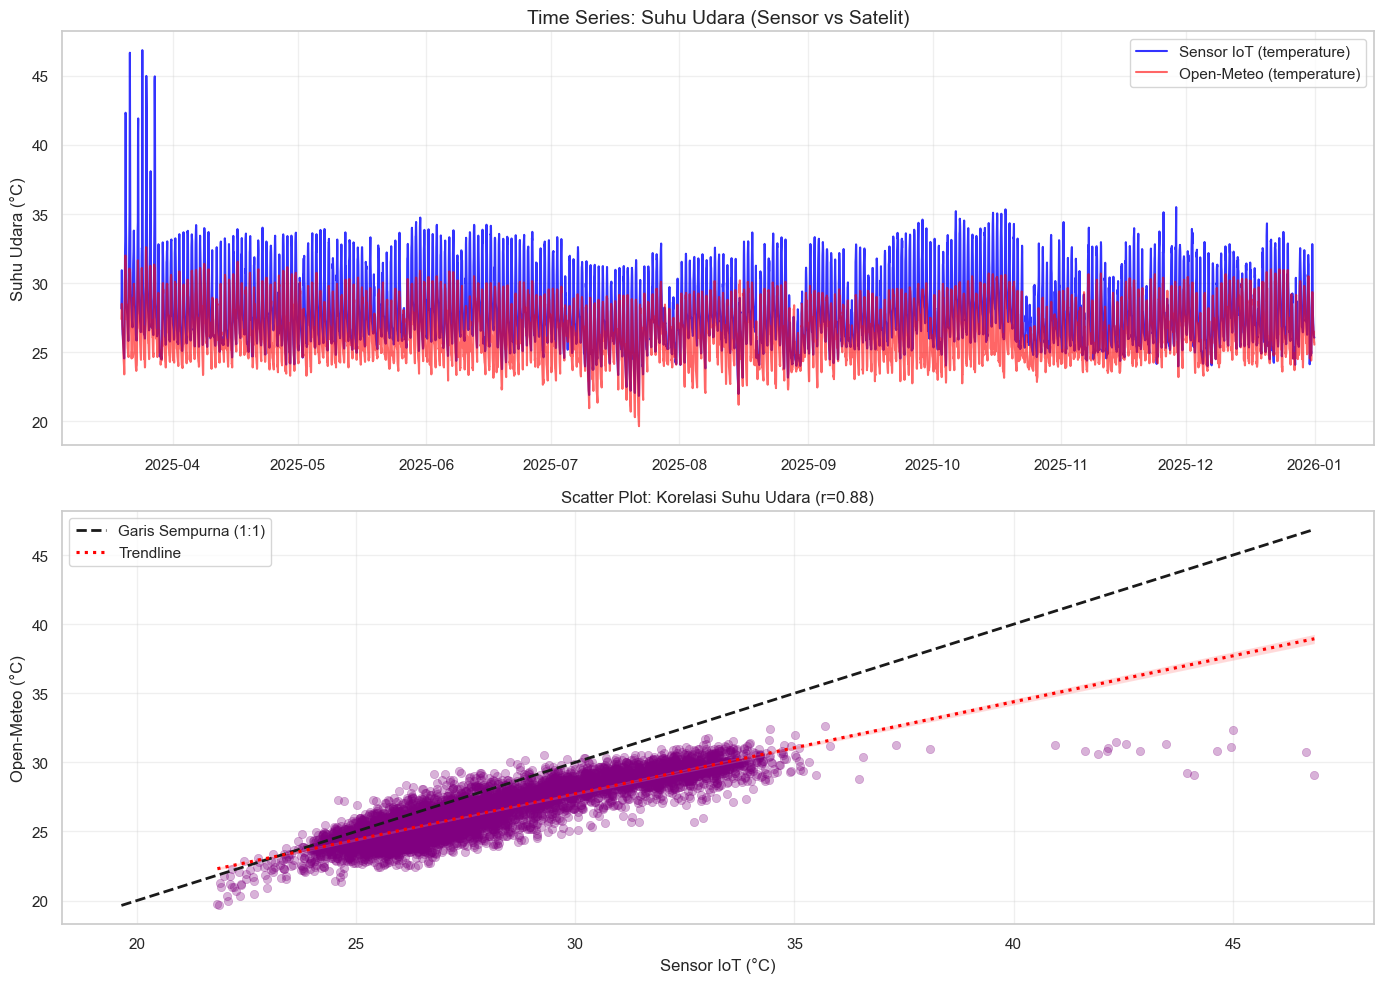


📊 ANALISIS PERBANDINGAN: KELEMBAPAN
1. Statistik Error:
   - MAE  : 5.38 %
   - RMSE : 7.12 %
   - Bias Max (Kampus - Desa): 34.79 %
   - Bias Min (Kampus - Desa): -31.42 %
   - Bias (Rata-rata Selisih): -3.61 %

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8217
   - Spearman (Ranking)  : 0.8229


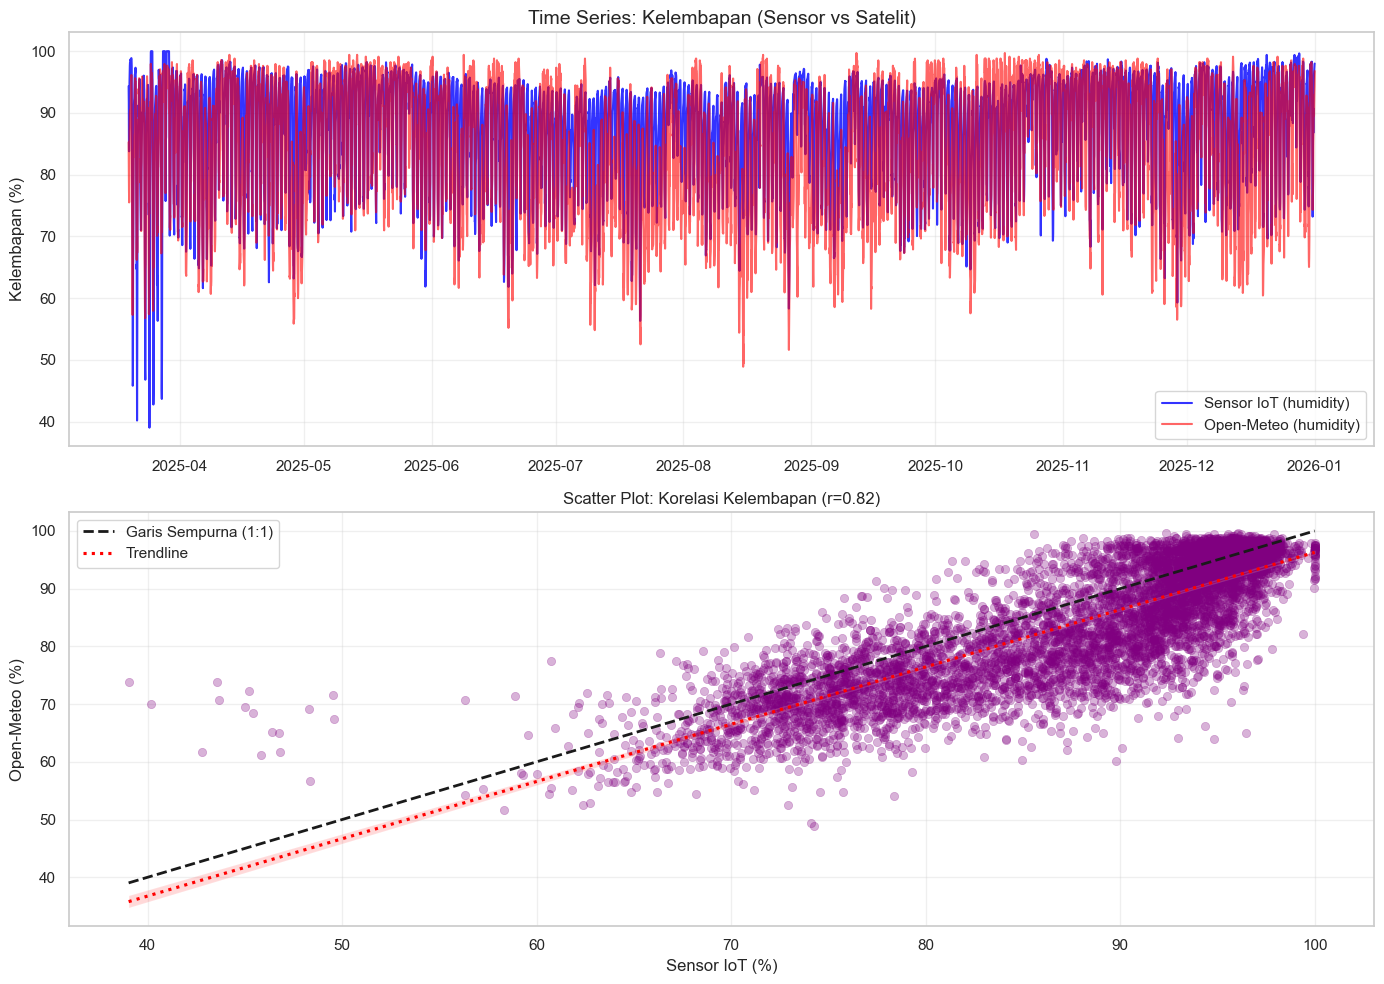


📊 ANALISIS PERBANDINGAN: TEKANAN UDARA
1. Statistik Error:
   - MAE  : 2.38 hPa
   - RMSE : 2.46 hPa
   - Bias Max (Kampus - Desa): -0.24 hPa
   - Bias Min (Kampus - Desa): -4.74 hPa
   - Bias (Rata-rata Selisih): -2.38 hPa

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.9445
   - Spearman (Ranking)  : 0.9368


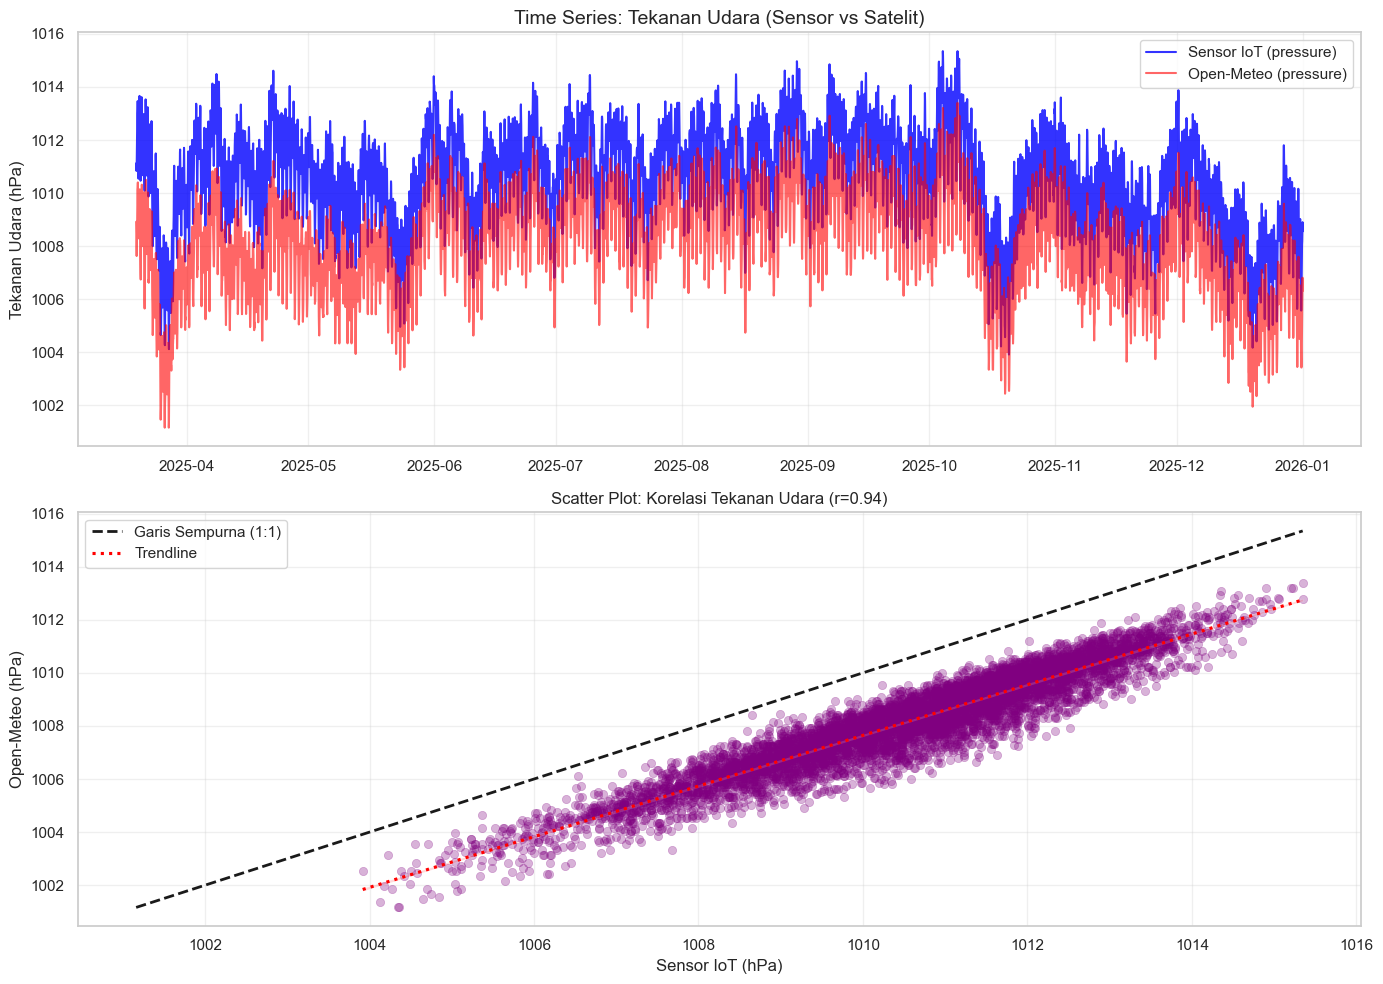


📊 ANALISIS PERBANDINGAN: CURAH HUJAN
1. Statistik Error:
   - MAE  : 0.78 mm/jam
   - RMSE : 3.08 mm/jam
   - Bias Max (Kampus - Desa): 19.42 mm/jam
   - Bias Min (Kampus - Desa): -57.00 mm/jam
   - Bias (Rata-rata Selisih): -0.30 mm/jam

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.1319
   - Spearman (Ranking)  : 0.2637


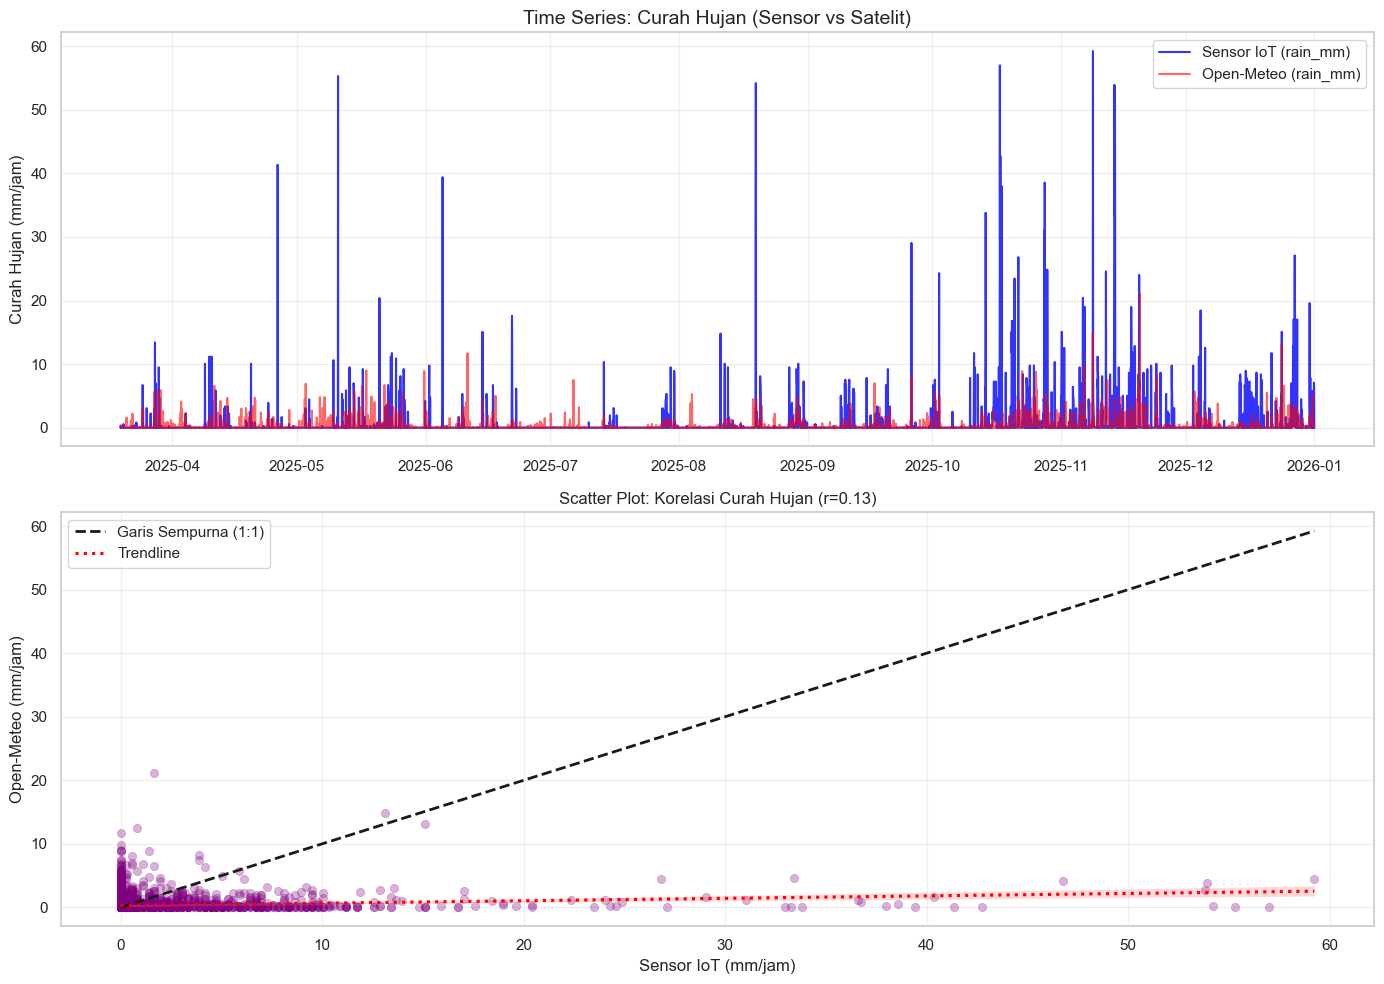

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

def bandingkan_variabel(target_sensor, target_meteo, nama_variabel, satuan):
    """
    Fungsi untuk membandingkan data Sensor vs Open-Meteo
    """
    print(f"\n" + "="*60)
    print(f"📊 ANALISIS PERBANDINGAN: {nama_variabel.upper()}")
    print("="*60)

    # 1. SIAPKAN DATA (Merge & Align)
    # Pastikan nama kolom ada
    if target_sensor not in df_hourly.columns:
        print(f"❌ Error: Kolom sensor '{target_sensor}' tidak ditemukan.")
        return
    if target_meteo not in df_desa.columns:
        print(f"❌ Error: Kolom Open-Meteo '{target_meteo}' tidak ditemukan.")
        return

    # Inner Join berdasarkan Index Waktu
    df_compare = pd.merge(
        df_hourly[[target_sensor]], 
        df_desa[[target_meteo]], 
        left_index=True, 
        right_index=True, 
        suffixes=('_sensor', '_satelit')
    )
    
    # Hapus NaN (jika ada bolong)
    df_compare = df_compare.dropna()
    
    # Ambil Series untuk memudahkan perhitungan
    x = df_compare[f'{target_sensor}_sensor']
    y = df_compare[f'{target_meteo}_satelit']

    # 2. HITUNG STATISTIK ERROR
    mae = mean_absolute_error(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    bias_max = (y - x).max() # Rata-rata selisih (Kampus - Desa)
    bias_min = (y - x).min() # Rata-rata selisih (Kampus - Desa)
    bias = (y - x).mean() # Rata-rata selisih (K
    
    # Korelasi
    corr_p = x.corr(y, method='pearson')
    corr_s, _ = spearmanr(x, y)

    print(f"1. Statistik Error:")
    print(f"   - MAE  : {mae:.2f} {satuan}")
    print(f"   - RMSE : {rmse:.2f} {satuan}")
    print(f"   - Bias Max (Kampus - Desa): {bias_max:.2f} {satuan}")
    print(f"   - Bias Min (Kampus - Desa): {bias_min:.2f} {satuan}")
    print(f"   - Bias (Rata-rata Selisih): {bias:.2f} {satuan}")

    print(f"\n2. Statistik Hubungan:")
    print(f"   - Pearson (Linear)    : {corr_p:.4f}")
    print(f"   - Spearman (Ranking)  : {corr_s:.4f}")

    # 3. VISUALISASI
    plt.figure(figsize=(14, 10))

    # --- PLOT A: TIME SERIES (Grafik Garis) ---
    plt.subplot(2, 1, 1)
    # Plot data (ambil sampel 300 jam terakhir biar detail, atau semua kalau mau)
    # Hapus .tail(300) kalau mau lihat setahun full
    df_plot = df_compare 
    
    plt.plot(df_plot.index, df_plot[f'{target_sensor}_sensor'], 
             label=f'Sensor IoT ({target_sensor})', 
             color='blue', 
             alpha=0.8)
    plt.plot(df_plot.index, df_plot[f'{target_meteo}_satelit'], 
             label=f'Open-Meteo ({target_meteo})', 
             color='red', 
             alpha=0.6)
    
    plt.title(f'Time Series: {nama_variabel} (Sensor vs Satelit)', fontsize=14)
    plt.ylabel(f'{nama_variabel} ({satuan})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- PLOT B: SCATTER PLOT (Validasi Linearitas) ---
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=x, y=y, alpha=0.3, color='purple', edgecolor=None)

    # Garis Identitas 1:1
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Garis Sempurna (1:1)')

    # Garis Regresi (Trend Asli)
    sns.regplot(x=x, y=y, scatter=False, color='red', label='Trendline', line_kws={'linestyle':':'})

    plt.xlabel(f'Sensor IoT ({satuan})')
    plt.ylabel(f'Open-Meteo ({satuan})')
    plt.title(f'Scatter Plot: Korelasi {nama_variabel} (r={corr_p:.2f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 🚀 CARA PAKAI (CONTOH)
# ==============================================================================

# Cek dulu nama kolom di open meteo kamu apa aja
# print(df_desa_2025.columns) 

bandingkan_variabel('temperature', 'temperature', 'Suhu Udara', '°C')
bandingkan_variabel('humidity', 'humidity', 'Kelembapan', '%')
bandingkan_variabel('pressure', 'pressure', 'Tekanan Udara', 'hPa')
bandingkan_variabel('rain_mm', 'rain_mm', 'Curah Hujan', 'mm/jam')

